# Adaptive Lifelong IRL for Human-Robot Collaboration

HRI/ICRA-ready implementation with:
- Importance-weighted MaxEnt IRL on demo-augmented MDP
- Adaptive temporal weight decay (interaction_step-based timing)
- Empirically derived overlap threshold (no hardcoded values)
- Baseline comparison: NoReplay, UniformWeight, FixedDecay vs Proposed
- Held-out evaluation to distinguish reward generalisation from memorisation

## Cell 1: Imports and Domain Constants, State Tracker, Recipe Generator

In [1]:
import re, json, random, string, gc, itertools
import numpy as np
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
matplotlib.rcParams['figure.dpi'] = 110

RANDOM_SEED   = 42
SHOW_STEPS    = False    # per-step action predictions during online observation
SHOW_CF_STEPS = False    # per-step predictions in forgetting checks
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Kitchen Domain Vocabulary (single source of truth)
CONTAINERS         = ["pot", "pan", "plate", "bowl", "glass", "measuring_cup"]
LIQUID_INGREDIENTS = ["milk", "oil"]
SOLID_INGREDIENTS  = ["tomato", "garlic", "onion", "mushroom", "lettuce",
                       "cheese", "rice", "yoghurt", "strawberries", "banana",
                       "egg", "fish", "chicken", "meat",
                       "salt", "spice1", "spice2", "mixture"]
INGREDIENTS = LIQUID_INGREDIENTS + SOLID_INGREDIENTS
ITEMS       = CONTAINERS + INGREDIENTS
CUTTABLES   = ["tomato", "onion", "mushroom", "lettuce", "banana", "strawberries", "chicken", "fish", "cheese"]
GRATABLE    = ["cheese"]
COOKABLES   = ["meat", "egg", "rice", "tomato", "onion", "mushroom", "chicken", "fish", "mixture"]
SEASONINGS  = ["salt", "spice1", "spice2", "garlic"]
LOCATIONS   = ["storage", "prep_station", "cooking_station", "plating_station", "serving_station", "washing_station", "blending_station"]
TOOLS       = {"prep_station":  ["cutting_board", "grater"],        "cooking_station":  ["stove"],          "washing_station":  ["sink"],       "blending_station":  ["blender"]}








#   The feature_map is built once at class level (not per-instance) to avoid constructing a throwaway object just to read the vocabulary. The feature_map is a dict mapping from "feature name" to column index in the raw state vector. 
#   The feature names are constructed systematically from the vocabulary, so that all possible features are pre-defined and the same across all instances. The feature_map is built on first access and then cached for all future instances.
class StateTracker:
    _CLASS_FEATURE_MAP = None   # built once, shared across all instances
    @classmethod
    def _build_feature_map(cls):
        if cls._CLASS_FEATURE_MAP is not None:      return cls._CLASS_FEATURE_MAP
        fm, idx = {}, 0
        for item in ITEMS:
            for loc in LOCATIONS:                   fm[f"{item}_at_{loc}"] = idx; idx += 1
        for container in CONTAINERS:
            for ingredient in INGREDIENTS:          fm[f"{container}_contains_{ingredient}"] = idx; idx += 1
        for item in CUTTABLES:                      fm[f"{item}_cut"] = idx; idx += 1
        for item in GRATABLE:                       fm[f"{item}_grated"] = idx; idx += 1
        for item in COOKABLES:                      fm[f"{item}_cooked"] = idx; idx += 1
        for item in INGREDIENTS:                    fm[f"{item}_seasoned"] = idx; idx += 1
        for item in ITEMS:                          fm[f"{item}_washed"] = idx; idx += 1
        fm["stove_on"]    = idx; idx += 1
        fm["sink_on"]     = idx; idx += 1
        fm["blender_on"]  = idx; idx += 1
        fm["plate_served"]= idx; idx += 1
        for ingredient in INGREDIENTS:
            if ingredient != "mixture":             fm[f"{ingredient}_in_mixture"] = idx; idx += 1
        for seasoning in SEASONINGS:
            for item in INGREDIENTS:                fm[f"{item}_seasoned_with_{seasoning}"] = idx; idx += 1
        cls._CLASS_FEATURE_MAP = fm
        return fm

    def __init__(self):
        self.feature_map = self.__class__._build_feature_map()
        self.n_features  = len(self.feature_map)
        self.reset()

    def reset(self):
        self.current_state = np.zeros(self.n_features, dtype=int)
        for item in ITEMS:
            if item != "mixture":
                self.set_feature(f"{item}_at_storage", 1)

    def set_feature(self, key, value):
        if key in self.feature_map:
            self.current_state[self.feature_map[key]] = value

    def get_feature(self, key):
        return self.current_state[self.feature_map[key]] if key in self.feature_map else 0

    def get_state_vector(self):
        return self.current_state.copy()

    def get_item_location(self, item):
        for loc in LOCATIONS:
            if self.get_feature(f"{item}_at_{loc}") == 1:
                return loc
        return None

    def is_contained(self, item):
        for container in CONTAINERS:
            if self.get_feature(f"{container}_contains_{item}") == 1:
                return container
        return None

    def apply_action(self, action_str):
        action_str = action_str.strip()
        def _parse(s):
            content = s[s.find("(")+1:s.find(")")]
            return [p.strip() for p in content.split(",")]
        def _loc(part):
            return part.split("=")[1] if "=" in part else part

        if action_str.startswith("transfer"):
            parts    = _parse(action_str)
            item     = parts[0]
            from_loc = _loc(parts[1])
            to_loc   = _loc(parts[2])
            if self.get_feature(f"{item}_at_{from_loc}") != 1:
                raise ValueError(f"Precondition failed: {item} not at {from_loc}")
            if self.is_contained(item):
                raise ValueError(f"Precondition failed: {item} is contained")
            self.set_feature(f"{item}_at_{from_loc}", 0)
            self.set_feature(f"{item}_at_{to_loc}",   1)

        elif action_str.startswith("load"):
            parts     = _parse(action_str)
            item      = parts[0]; container = parts[1]; location = parts[2]
            if self.get_feature(f"{item}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {item} not at {location}")
            if self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {location}")
            if self.is_contained(item):
                raise ValueError(f"Precondition failed: {item} already contained")
            self.set_feature(f"{item}_at_{location}", 0)
            self.set_feature(f"{container}_contains_{item}", 1)

        elif action_str.startswith("unload"):
            parts     = _parse(action_str)
            item      = parts[0]; container = parts[1]; location = parts[2]
            if self.get_feature(f"{container}_contains_{item}") != 1:
                raise ValueError(f"Precondition failed: {item} not in {container}")
            if self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {location}")
            self.set_feature(f"{container}_contains_{item}", 0)
            self.set_feature(f"{item}_at_{location}", 1)

        elif action_str.startswith("move_container"):
            parts     = _parse(action_str)
            container = parts[0]; from_loc = _loc(parts[1]); to_loc = _loc(parts[2])
            if self.get_feature(f"{container}_at_{from_loc}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {from_loc}")
            self.set_feature(f"{container}_at_{from_loc}", 0)
            self.set_feature(f"{container}_at_{to_loc}", 1)
            for ingredient in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ingredient}") == 1:
                    self.set_feature(f"{ingredient}_at_{from_loc}", 0)
                    self.set_feature(f"{ingredient}_at_{to_loc}", 1)

        elif action_str.startswith("cut"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "prep_station"
            if item not in CUTTABLES:
                raise ValueError(f"Precondition failed: {item} is not cuttable")
            if self.get_feature(f"{item}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {item} not at {location}")
            self.set_feature(f"{item}_cut", 1)

        elif action_str.startswith("grate"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "prep_station"
            if item not in GRATABLE:
                raise ValueError(f"Precondition failed: {item} is not gratable")
            if self.get_feature(f"{item}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {item} not at {location}")
            self.set_feature(f"{item}_grated", 1)

        elif action_str.startswith("cook ") or action_str.startswith("cook("):
            parts     = _parse(action_str)
            item      = parts[0]
            container = parts[1] if len(parts) > 1 else "pot"
            location  = parts[2] if len(parts) > 2 else "cooking_station"
            if item not in COOKABLES:
                raise ValueError(f"Precondition failed: {item} is not cookable")
            if self.get_feature(f"{container}_contains_{item}") != 1:
                raise ValueError(f"Precondition failed: {item} not in {container}")
            if self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {location}")
            if location == "cooking_station" and self.get_feature("stove_on") != 1:
                raise ValueError("Precondition failed: stove not on")
            self.set_feature(f"{item}_cooked", 1)

        elif action_str.startswith("cook_contents"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else "cooking_station"
            if self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {location}")
            if location == "cooking_station" and self.get_feature("stove_on") != 1:
                raise ValueError("Precondition failed: stove not on")
            for ingredient in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ingredient}") == 1:
                    if ingredient in COOKABLES:
                        self.set_feature(f"{ingredient}_cooked", 1)

        elif action_str.startswith("combine"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else None
            if location and self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"Precondition failed: {container} not at {location}")
            contained = [ing for ing in INGREDIENTS
                         if ing != "mixture" and self.get_feature(f"{container}_contains_{ing}") == 1]
            if len(contained) < 2:
                raise ValueError(f"combine requires >=2 ingredients in {container}")
            for ing in contained:
                self.set_feature(f"{container}_contains_{ing}", 0)
                self.set_feature(f"{ing}_in_mixture", 1)
            self.set_feature(f"{container}_contains_mixture", 1)
            if location:
                self.set_feature(f"mixture_at_{location}", 1)

        elif action_str.startswith("season_container"):
            parts     = _parse(action_str)
            container = parts[0]; seasoning = parts[1]
            location  = parts[2] if len(parts) > 2 else None
            if seasoning not in SEASONINGS:
                raise ValueError(f"{seasoning} is not a seasoning")
            if location and self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"{container} not at {location}")
            for ing in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ing}") == 1:
                    self.set_feature(f"{ing}_seasoned", 1)
                    self.set_feature(f"{ing}_seasoned_with_{seasoning}", 1)

        elif action_str.startswith("season"):
            parts     = _parse(action_str)
            target    = parts[0]; seasoning = parts[1]
            location  = parts[2] if len(parts) > 2 else None
            if seasoning not in SEASONINGS:
                raise ValueError(f"{seasoning} is not a seasoning")
            if location and self.get_feature(f"{target}_at_{location}") != 1:
                raise ValueError(f"{target} not at {location}")
            self.set_feature(f"{target}_seasoned", 1)
            self.set_feature(f"{target}_seasoned_with_{seasoning}", 1)

        elif action_str.startswith("pour"):
            parts          = _parse(action_str)
            liquid         = parts[0]; from_c = parts[1]; to_c = parts[2]
            location       = parts[3] if len(parts) > 3 else None
            if liquid not in LIQUID_INGREDIENTS:
                raise ValueError(f"{liquid} is not a liquid")
            if self.get_feature(f"{from_c}_contains_{liquid}") != 1:
                raise ValueError(f"{liquid} not in {from_c}")
            if location:
                if self.get_feature(f"{from_c}_at_{location}") != 1:
                    raise ValueError(f"{from_c} not at {location}")
                if self.get_feature(f"{to_c}_at_{location}") != 1:
                    raise ValueError(f"{to_c} not at {location}")
            self.set_feature(f"{from_c}_contains_{liquid}", 0)
            self.set_feature(f"{to_c}_contains_{liquid}", 1)
            if location:
                self.set_feature(f"{liquid}_at_{location}", 1)

        elif action_str.startswith("turn_on"):
            tool = _parse(action_str)[0]
            if   tool == "stove":   self.set_feature("stove_on",   1)
            elif tool == "sink":    self.set_feature("sink_on",    1)
            elif tool == "blender": self.set_feature("blender_on", 1)

        elif action_str.startswith("turn_off"):
            tool = _parse(action_str)[0]
            if   tool == "stove":   self.set_feature("stove_on",   0)
            elif tool == "sink":    self.set_feature("sink_on",    0)
            elif tool == "blender": self.set_feature("blender_on", 0)

        elif action_str.startswith("blend"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else "blending_station"
            if self.get_feature(f"{container}_at_{location}") != 1:
                raise ValueError(f"{container} not at {location}")
            if self.get_feature("blender_on") != 1:
                raise ValueError("blender not on")
            contained = [ing for ing in INGREDIENTS
                         if ing != "mixture" and self.get_feature(f"{container}_contains_{ing}") == 1]
            if len(contained) < 1:
                raise ValueError(f"blend requires >=1 ingredient in {container}")
            for ing in contained:
                self.set_feature(f"{container}_contains_{ing}", 0)
                self.set_feature(f"{ing}_in_mixture", 1)
            self.set_feature(f"{container}_contains_mixture", 1)
            self.set_feature(f"mixture_at_{location}", 1)

        elif action_str.startswith("serve"):
            parts    = _parse(action_str)
            plate    = parts[0]
            location = parts[1] if len(parts) > 1 else "serving_station"
            if self.get_feature(f"{plate}_at_{location}") != 1:
                raise ValueError(f"{plate} not at {location}")
            self.set_feature("plate_served", 1)

        elif action_str.startswith("wash"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "washing_station"
            if self.get_feature(f"{item}_at_{location}") != 1:
                raise ValueError(f"{item} not at {location}")
            self.set_feature(f"{item}_washed", 1)

        else:
            raise ValueError(f"Unknown action: {action_str}")


# Module-level feature map reference (single object, not rebuilt per call)
_FEAT = StateTracker._build_feature_map()

_t = StateTracker()
print(f"{_t.n_features} raw state features")








class RecipeGenerator:
    def __init__(self):
        self.demos   = []
        self.tracker = StateTracker()

    def _record_trajectory(self, actions):
        self.tracker.reset()
        trajectory = []
        for action in actions:
            state_vector = self.tracker.get_state_vector().tolist()
            trajectory.append({"state": state_vector, "action": action})
            try:
                self.tracker.apply_action(action)
            except ValueError as e:
                print(f"ERROR applying action '{action}': {e}")
                raise
        final_state_vector = self.tracker.get_state_vector().tolist()
        trajectory.append({"state": final_state_vector, "action": "stop"})
        self.demos.append(trajectory)

    def generate_grilled_steak(self): return [
        "transfer (pan, from=storage, to=cooking_station)",
        "load (meat, bowl, storage)",
        "move_container (bowl, from=storage, to=cooking_station)",
        "unload (meat, bowl, cooking_station)",
        "load (meat, pan, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pan, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (meat, pan, cooking_station)",
        "load (meat, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (meat, bowl, plating_station)",
        "load (meat, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pan, from=cooking_station, to=washing_station)",
        "wash (pan, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_boiled_eggs(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "load (egg, bowl, storage)",
        "move_container (bowl, from=storage, to=cooking_station)",
        "unload (egg, bowl, cooking_station)",
        "load (egg, pot, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (pot, from=cooking_station, to=plating_station)",
        "unload (egg, pot, plating_station)",
        "load (egg, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pot, from=plating_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=cooking_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_boiled_rice(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "load (rice, bowl, storage)",
        "move_container (bowl, from=storage, to=cooking_station)",
        "unload (rice, bowl, cooking_station)",
        "turn_on (stove, cooking_station)",
        "load (rice, pot, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (rice, pot, cooking_station)",
        "load (rice, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (rice, bowl, plating_station)",
        "load (rice, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pot, from=cooking_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_simple_salad(self): return [
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (lettuce, from=storage, to=prep_station)",
        "transfer (onion, from=storage, to=prep_station)",
        "cut (lettuce, prep_station)",
        "load (lettuce, bowl, prep_station)",
        "cut (onion, prep_station)",
        "load (onion, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (bowl, from=prep_station, to=plating_station)",
        "unload (mixture, bowl, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (plate, from=serving_station, to=washing_station)",
        "wash (plate, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_burger(self): return [
        "transfer (pan, from=storage, to=cooking_station)",
        "load (meat, bowl, storage)",
        "move_container (bowl, from=storage, to=cooking_station)",
        "unload (meat, bowl, cooking_station)",
        "load (meat, pan, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pan, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (meat, pan, cooking_station)",
        "load (meat, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (meat, bowl, plating_station)",
        "load (meat, plate, plating_station)",
        "transfer (lettuce, from=storage, to=prep_station)",
        "move_container (bowl, from=plating_station, to=prep_station)",
        "cut (lettuce, prep_station)",
        "load (lettuce, bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=plating_station)",
        "unload (lettuce, bowl, plating_station)",
        "load (lettuce, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pan, from=cooking_station, to=washing_station)",
        "wash (pan, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_tomato_soup(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "turn_on (stove, cooking_station)",
        "transfer (tomato, from=storage, to=prep_station)",
        "cut (tomato, prep_station)",
        "load (tomato, bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (tomato, bowl, cooking_station)",
        "load (tomato, pot, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (tomato, pot, cooking_station)",
        "load (tomato, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (tomato, bowl, plating_station)",
        "load (tomato, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pot, from=cooking_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_tomato_onion_soup_v1(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (tomato, from=storage, to=prep_station)",
        "cut (tomato, prep_station)",
        "load (tomato, bowl, prep_station)",
        "transfer (onion, from=storage, to=prep_station)",
        "cut (onion, prep_station)",
        "load (onion, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (mixture, bowl, cooking_station)",
        "load (mixture, pot, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (pot, from=cooking_station, to=plating_station)",
        "unload (mixture, pot, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (pot, from=plating_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=cooking_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_tomato_onion_soup_v2(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (onion, from=storage, to=prep_station)",
        "cut (onion, prep_station)",
        "load (onion, bowl, prep_station)",
        "transfer (tomato, from=storage, to=prep_station)",
        "cut (tomato, prep_station)",
        "load (tomato, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (mixture, bowl, cooking_station)",
        "load (mixture, pot, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (pot, from=cooking_station, to=plating_station)",
        "unload (mixture, pot, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (pot, from=plating_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=cooking_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_mushroom_soup(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (mushroom, from=storage, to=prep_station)",
        "cut (mushroom, prep_station)",
        "load (mushroom, bowl, prep_station)",
        "transfer (onion, from=storage, to=prep_station)",
        "cut (onion, prep_station)",
        "load (onion, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (mixture, bowl, cooking_station)",
        "load (mixture, pot, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (pot, from=cooking_station, to=plating_station)",
        "unload (mixture, pot, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (pot, from=plating_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=cooking_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_seasoned_chicken(self): return [
        "transfer (pan, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (chicken, from=storage, to=prep_station)",
        "season (chicken, salt, prep_station)",
        "season (chicken, spice1, prep_station)",
        "load (chicken, bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (chicken, bowl, cooking_station)",
        "load (chicken, pan, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pan, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (chicken, pan, cooking_station)",
        "load (chicken, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (chicken, bowl, plating_station)",
        "load (chicken, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pan, from=cooking_station, to=washing_station)",
        "wash (pan, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_garlic_fish(self): return [
        "transfer (pan, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (fish, from=storage, to=prep_station)",
        "season (fish, garlic, prep_station)",
        "season (fish, spice2, prep_station)",
        "load (fish, bowl, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (fish, bowl, cooking_station)",
        "load (fish, pan, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pan, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "unload (fish, pan, cooking_station)",
        "load (fish, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (fish, bowl, plating_station)",
        "load (fish, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pan, from=cooking_station, to=washing_station)",
        "wash (pan, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_seasoned_mixture_soup(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (tomato, from=storage, to=prep_station)",
        "cut (tomato, prep_station)",
        "load (tomato, bowl, prep_station)",
        "transfer (onion, from=storage, to=prep_station)",
        "cut (onion, prep_station)",
        "load (onion, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "season_container (bowl, salt, prep_station)",
        "season_container (bowl, spice1, prep_station)",
        "move_container (bowl, from=prep_station, to=cooking_station)",
        "unload (mixture, bowl, cooking_station)",
        "load (mixture, pot, cooking_station)",
        "turn_on (stove, cooking_station)",
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (pot, from=cooking_station, to=plating_station)",
        "unload (mixture, pot, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (pot, from=plating_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=cooking_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_grated_cheese_salad(self): return [
        "transfer (bowl, from=storage, to=prep_station)",
        "transfer (lettuce, from=storage, to=prep_station)",
        "transfer (cheese, from=storage, to=prep_station)",
        "cut (lettuce, prep_station)",
        "load (lettuce, bowl, prep_station)",
        "grate (cheese, prep_station)",
        "load (cheese, bowl, prep_station)",
        "combine (bowl, prep_station)",
        "transfer (plate, from=storage, to=plating_station)",
        "move_container (bowl, from=prep_station, to=plating_station)",
        "unload (mixture, bowl, plating_station)",
        "load (mixture, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "move_container (plate, from=serving_station, to=washing_station)",
        "wash (plate, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]

    def generate_smoothie(self): return [
        "transfer (glass, from=storage, to=blending_station)",
        "transfer (measuring_cup, from=storage, to=blending_station)",
        "transfer (banana, from=storage, to=prep_station)",
        "transfer (strawberries, from=storage, to=prep_station)",
        "cut (banana, prep_station)",
        "transfer (banana, from=prep_station, to=blending_station)",
        "cut (strawberries, prep_station)",
        "transfer (strawberries, from=prep_station, to=blending_station)",
        "transfer (milk, from=storage, to=blending_station)",
        "load (milk, measuring_cup, blending_station)",
        "pour (milk, measuring_cup, glass, blending_station)",
        "load (banana, glass, blending_station)",
        "load (strawberries, glass, blending_station)",
        "turn_on (blender, blending_station)",
        "blend (glass, blending_station)",
        "turn_off (blender, blending_station)",
        "transfer (glass, from=blending_station, to=serving_station)",
        "serve (glass, serving_station)",
        "transfer (measuring_cup, from=blending_station, to=washing_station)",
        "wash (measuring_cup, washing_station)"]

    def generate_yoghurt_smoothie(self): return [
        "transfer (glass, from=storage, to=blending_station)",
        "transfer (measuring_cup, from=storage, to=blending_station)",
        "transfer (banana, from=storage, to=prep_station)",
        "transfer (yoghurt, from=storage, to=blending_station)",
        "cut (banana, prep_station)",
        "transfer (banana, from=prep_station, to=blending_station)",
        "load (yoghurt, glass, blending_station)",
        "transfer (milk, from=storage, to=blending_station)",
        "load (milk, measuring_cup, blending_station)",
        "pour (milk, measuring_cup, glass, blending_station)",
        "load (banana, glass, blending_station)",
        "turn_on (blender, blending_station)",
        "blend (glass, blending_station)",
        "turn_off (blender, blending_station)",
        "transfer (glass, from=blending_station, to=serving_station)",
        "serve (glass, serving_station)",
        "transfer (measuring_cup, from=blending_station, to=washing_station)",
        "wash (measuring_cup, washing_station)"]

    def generate_random_dataset(self, count):
        """Generate count demonstrations drawn uniformly from ALL available recipes."""
        available_recipes = [
            self.generate_tomato_onion_soup_v1, self.generate_tomato_onion_soup_v2,
            self.generate_tomato_soup,          self.generate_mushroom_soup,
            self.generate_seasoned_mixture_soup, self.generate_grilled_steak,
            self.generate_burger,               self.generate_seasoned_chicken,
            self.generate_garlic_fish,          self.generate_simple_salad,
            self.generate_grated_cheese_salad,  self.generate_smoothie,
            self.generate_yoghurt_smoothie,     self.generate_boiled_eggs,
            self.generate_boiled_rice,
        ]
        print(f"Generating {count} demonstrations from {len(available_recipes)} recipes...")
        for _ in range(count):
            recipe_func = random.choice(available_recipes)
            actions     = recipe_func()
            self._record_trajectory(actions)

    def save_to_file(self, filepath="demonstrations.txt"):
        with open(filepath, "w") as f:
            for demo in self.demos:
                f.write(json.dumps(demo) + "\n")
        print(f"Saved {len(self.demos)} trajectories → {filepath}")

gen = RecipeGenerator()
print(f"{len([m for m in dir(gen) if m.startswith('generate_')])} recipes defined")

470 raw state features
16 recipes defined


## Cell 2: Feature Engineering, IRL, Demo-Augmented MDP MaxEnt

In [2]:
#  _safe_feat helper eliminates ~120 lines of repeated key-lookup patterns. create_enhanced_feature_matrix is the single source of engineered features; its output dimensionality is FIXED by the constant vocabulary lists, so warm-starting across retrains is always valid.

def _safe_feat(state, key):
    """Return state[_FEAT[key]] if key exists, else 0. Avoids key-error boilerplate."""
    return int(state[_FEAT[key]]) if key in _FEAT else 0

def create_state_action_mappings(demonstrations, unique_actions):
    """Bidirectional mappings: state ↔ index, action ↔ index."""
    state_to_idx = {}
    for trajectory in demonstrations:
        for state, _ in trajectory:
            if state not in state_to_idx:
                state_to_idx[state] = len(state_to_idx)
    idx_to_state  = {idx: state for state, idx in state_to_idx.items()}
    action_to_idx = {action: idx for idx, action in enumerate(unique_actions)}
    idx_to_action = {idx: action for action, idx in action_to_idx.items()}
    return state_to_idx, idx_to_state, action_to_idx, idx_to_action

def create_enhanced_feature_matrix(idx_to_state, col_min_known=None, col_max_known=None):
    """
    Task-discriminative feature matrix from PDDL kitchen states. All raw-state column accesses use the module-level _FEAT dict. The engineered feature dimension is determined entirely by the fixed vocabulary constants below, not by data size, so it is stable across every retrain cycle and warm-starting is always valid.
    Parameters:
    idx_to_state   : {int: state_tuple}
    col_min_known  : normalisation lower bounds from a prior training call
    col_max_known  : normalisation upper bounds (pass for test states)
    Returns:    feature_matrix, col_min, col_max
    """
    KEY_INGREDIENTS = [
        "tomato", "onion", "mushroom", "rice", "meat",
        "chicken", "fish", "egg", "banana", "strawberries",
        "lettuce", "cheese", "garlic", "yoghurt", "milk",
    ]
    KEY_CONTAINERS = ["pot", "pan", "plate", "bowl"]
    KEY_LOCS       = ["prep_station", "cooking_station", "plating_station", "blending_station"]

    features = []
    for idx in range(len(idx_to_state)):
        state = np.array(idx_to_state[idx])
        feat  = []

        # 1. Items per location (7 features)
        for loc in LOCATIONS:
            feat.append(sum(_safe_feat(state, f"{item}_at_{loc}") for item in ITEMS))

        # 2. Container × location presence (16 + 3 composite)
        for container, loc in [
            ("pot",          "cooking_station"),  ("pan",           "cooking_station"),
            ("plate",        "plating_station"),  ("plate",         "serving_station"),
            ("plate",        "washing_station"),  ("bowl",          "prep_station"),
            ("bowl",         "cooking_station"),  ("bowl",          "plating_station"),
            ("glass",        "blending_station"), ("measuring_cup", "blending_station"),
            ("glass",        "serving_station"),  ("pot",           "washing_station"),
            ("pan",          "washing_station"),  ("bowl",          "washing_station"),
            ("glass",        "washing_station"),  ("measuring_cup", "washing_station"),
        ]:
            feat.append(_safe_feat(state, f"{container}_at_{loc}"))
        cooking_vessel = (_safe_feat(state, "pot_at_cooking_station") + _safe_feat(state, "pan_at_cooking_station"))
        feat.append(cooking_vessel)
        feat.append(sum(_safe_feat(state, f"{item}_at_prep_station")     for item in ITEMS))
        feat.append(sum(_safe_feat(state, f"{item}_at_blending_station") for item in ITEMS))

        # 3. Containment aggregates (8 features)
        total_contained = sum(_safe_feat(state, f"{c}_contains_{i}") for c in CONTAINERS for i in INGREDIENTS)
        feat.append(total_contained)
        for container in CONTAINERS: feat.append(sum(_safe_feat(state, f"{container}_contains_{ing}") for ing in INGREDIENTS))
        feat.append(sum(_safe_feat(state, f"{c}_contains_mixture") for c in CONTAINERS))

        # 4. Processing-state features
        cut_vals    = [_safe_feat(state, f"{item}_cut")    for item in CUTTABLES]
        cooked_vals = [_safe_feat(state, f"{item}_cooked") for item in COOKABLES]
        feat.extend(cut_vals)
        feat.extend(cooked_vals)
        total_cut      = sum(cut_vals)
        total_cooked   = sum(cooked_vals)
        total_grated   = sum(_safe_feat(state, f"{item}_grated")   for item in GRATABLE)
        total_seasoned = sum(_safe_feat(state, f"{item}_seasoned")  for item in INGREDIENTS)
        total_washed   = sum(_safe_feat(state, f"{item}_washed")    for item in ITEMS)
        feat.extend([total_cut, total_grated, total_cooked, total_seasoned])
        for ing in ["chicken", "fish", "mixture"]: feat.append(_safe_feat(state, f"{ing}_seasoned"))
        feat.append(total_washed)

        # 5. Tool-usage features (6 features)
        stove_on   = _safe_feat(state, "stove_on")
        sink_on    = _safe_feat(state, "sink_on")
        blender_on = _safe_feat(state, "blender_on")
        items_in_glass = sum(_safe_feat(state, f"glass_contains_{ing}") for ing in INGREDIENTS)
        feat.extend([stove_on,      stove_on * cooking_vessel,      stove_on * total_contained,         sink_on, blender_on,        blender_on * items_in_glass])

        # 6. Workflow-progress features (11 features)
        served        = _safe_feat(state, "plate_served")
        items_in_plate = sum(_safe_feat(state, f"plate_contains_{ing}") for ing in INGREDIENTS)
        feat.extend([int(total_cut > 0), int(total_cooked > 0), int(items_in_plate > 0), int(items_in_glass > 0), served, int(total_washed > 0), int(total_grated > 0), int(total_seasoned > 0), int(total_cut > 0) * int(total_cooked > 0) * served * int(total_washed > 0), int(total_cut > 0) * served * int(total_washed > 0) * int(total_cooked == 0), served * int(total_washed > 0)])

        # 7-11. Discriminative features (ingredient × location/container/seasoning)
        for ing in KEY_INGREDIENTS:
            for loc in KEY_LOCS:
                feat.append(_safe_feat(state, f"{ing}_at_{loc}"))
        for ing in KEY_INGREDIENTS:
            for cont in KEY_CONTAINERS:
                feat.append(_safe_feat(state, f"{cont}_contains_{ing}"))
        for ing in KEY_INGREDIENTS:
            feat.append(_safe_feat(state, f"{ing}_seasoned"))
        for ing in KEY_INGREDIENTS:
            if ing in INGREDIENTS:
                feat.append(_safe_feat(state, f"{ing}_in_mixture"))
        for seasoning in SEASONINGS:
            for ing in KEY_INGREDIENTS:
                if ing in INGREDIENTS:
                    feat.append(_safe_feat(state, f"{ing}_seasoned_with_{seasoning}"))
        features.append(feat)

    feature_matrix = np.array(features, dtype=float)
    col_min   = col_min_known if col_min_known is not None else feature_matrix.min(axis=0)
    col_max   = col_max_known if col_max_known is not None else feature_matrix.max(axis=0)
    col_range = col_max - col_min
    col_range[col_range == 0] = 1.0
    feature_matrix = np.clip((feature_matrix - col_min) / col_range, 0.0, 1.0)
    return feature_matrix, col_min, col_max

_test_fm, _, _ = create_enhanced_feature_matrix({0: tuple(StateTracker().get_state_vector().tolist())})
print(f"✓ Feature engineering ready — engineered feature dim: {_test_fm.shape[1]} (fixed)")
# ═══════════════════════════════════════════════════════════════════════════════
#  IMPORTANCE-WEIGHTED MaxEnt IRL  —  Demo-Augmented MDP
#
#  Theoretical framing
#  ───────────────────
#  Standard MaxEnt IRL (Ziebart et al., 2008) requires expected feature counts under the learned policy over the FULL MDP.  With demo-only transitions, the expected counts equal the empirical counts → gradient ≈ 0 → no learning.
#
#  Fix: Demo-Augmented MDP
#  For each demonstrated state s, we add one virtual DEVIATE action whose transition leads to a null state (zero-feature absorbing state).  The soft Bellman VI must now assign Q(s, deviate) < Q(s, demonstrated) for the policy to prefer demonstrated actions.  
#  The expected feature counts under the learned policy can now differ from the empirical counts, making the IRL gradient non-trivial.  Demonstrated actions are rewarded; the deviate option is penalised by receiving zero features.
#  This is equivalent to "maximum entropy IRL on a demo-constrained MDP with a null alternative" — see Bloem & Bambos (2014) for theoretical grounding.
#
#  Importance weighting
#  ───────────────────────────────────────────────
#  θ* = argmax_θ  Σ_i w_i · log P(τ_i | θ) where w_i are the time-decayed demo weights from AdaptiveIRL. Recent demos contribute more to the gradient than stale ones.
#
#  Warm-starting validity
#  ──────────────────────
#  reward_weights ∈ R^n_features where n_features is determined by the FIXED vocabulary constants in create_enhanced_feature_matrix, NOT by data size. Adding new recipes only enlarges state/action index spaces, never n_features. Warm-starting is therefore always valid across every retrain cycle.
# ═══════════════════════════════════════════════════════════════════════════════

def max_ent_irl(demonstrations, feature_matrix, state_to_idx, action_to_idx, n_iterations=100, learning_rate=0.05, temperature=0.5, gamma=0.9, init_weights=None, demo_weights=None):
    n_states, n_features = feature_matrix.shape
    n_actions = len(action_to_idx)
    MC_Count  = min(max(150, 10 * len(demonstrations)), 400)
    verbose   = True


    # Normalise demo weights 
    w = (np.ones(len(demonstrations)) if demo_weights is None else np.array(demo_weights, dtype=float))
    w_sum = w.sum()
    if w_sum == 0: w, w_sum = np.ones(len(demonstrations)), float(len(demonstrations))
    demo_probs = w / w_sum

    if verbose: print(f"  MaxEnt IRL — States: {n_states}, Actions: {n_actions}, Features: {n_features}, MC rollouts: {MC_Count}")
    if verbose and demo_weights is not None:
        entropy     = float(-(demo_probs * np.log(demo_probs + 1e-12)).sum())
        max_entropy = float(np.log(max(len(demonstrations), 1)))
        uniformity  = entropy / max_entropy if max_entropy > 0 else 1.0
        print(f"  IW-MaxEnt weight-entropy={entropy:.3f}/{max_entropy:.3f}  uniformity={uniformity:.2f} (1.0=uniform, <1.0=recency-biased)")


    # Reward weights init
    if init_weights is not None and len(init_weights) == n_features:
        reward_weights = init_weights.copy()
        if verbose: print(f"  Warm-start ‖w‖={np.linalg.norm(init_weights):.3f}")
    else:
        reward_weights = np.random.randn(n_features) * 0.1
        if verbose: print(f"  Random init (first cycle or dim mismatch)")


    # Build base transition model and s_to_actions
    state_action_pairs = set()
    transition_model   = {}
    s_to_actions       = {}

    for trajectory in demonstrations:
        for i in range(len(trajectory)):
            state, action = trajectory[i]
            s_idx = state_to_idx[state]
            a_idx = action_to_idx[action]
            state_action_pairs.add((s_idx, a_idx))
            s_to_actions.setdefault(s_idx, [])
            if a_idx not in s_to_actions[s_idx]:    s_to_actions[s_idx].append(a_idx)
            if i < len(trajectory) - 1:             transition_model[(s_idx, a_idx)] = state_to_idx[trajectory[i+1][0]]


    # Demo-Augmented MDP
    # Add one DEVIATE action per demonstrated state → null state. The null state has a zero feature vector and no outgoing transitions. This gives the soft Bellman VI a non-trivial contrast at every state, making the expected feature counts under the policy differ from empirical.
    DEVIATE_A     = n_actions        # virtual action index
    NULL_S        = n_states         # virtual null state index
    null_row      = np.zeros((1, n_features), dtype=float)
    feat_aug      = np.vstack([feature_matrix, null_row])   # (n_states+1, n_features)
    n_states_aug  = n_states + 1

    for s_idx in list(s_to_actions.keys()):
        transition_model[(s_idx, DEVIATE_A)] = NULL_S
        s_to_actions[s_idx] = s_to_actions[s_idx] + [DEVIATE_A]

    # Weighted empirical feature expectations
    empirical_fe = np.zeros(n_features)
    demo_starts  = [state_to_idx[demonstrations[i][0][0]] for i in range(len(demonstrations))]
    for i, trajectory in enumerate(demonstrations):
        traj_fe = np.zeros(n_features)
        for t, (state, _) in enumerate(trajectory):
            s_idx       = state_to_idx[state]
            traj_fe     += (gamma ** t) * feature_matrix[s_idx]   # original feature_matrix (no null)
        empirical_fe    += w[i] * traj_fe
    empirical_fe /= w_sum

    if verbose: print(f"  {len(state_action_pairs)} demo (s,a) pairs  ‖μ_emp‖={np.linalg.norm(empirical_fe):.4f}  null-state augmentation active")


    # Gradient ascent with soft Bellman VI on augmented MDP
    rewards  = feat_aug @ reward_weights      # (n_states_aug,)
    values   = rewards.copy()
    q_values = {}
    best_diff, best_weights = float('inf'), reward_weights.copy()
    momentum, momentum_beta = np.zeros(n_features), 0.9
    no_improve = 0

    for iteration in range(n_iterations):
        lr      = learning_rate * (0.97 ** (no_improve // 20))
        rewards = feat_aug @ reward_weights

        # Soft Bellman VI (augmented)
        for _ in range(50):
            new_values = rewards.copy()
            for (s_idx, a_idx) in state_action_pairs:
                ns = transition_model.get((s_idx, a_idx))
                q_values[(s_idx, a_idx)] = rewards[s_idx] + (gamma * values[ns] if ns is not None else 0.0)
            # Deviate transitions
            for s_idx in s_to_actions:
                if (s_idx, DEVIATE_A) not in q_values: q_values[(s_idx, DEVIATE_A)] = rewards[s_idx] + gamma * values[NULL_S]
            for s_idx, a_list in s_to_actions.items():
                avail = np.array([q_values.get((s_idx, a), rewards[s_idx]) for a in a_list])
                max_q = avail.max()
                new_values[s_idx] = (max_q + temperature * np.log(np.sum(np.exp((avail - max_q) / temperature))))
            delta  = np.max(np.abs(new_values - values))
            values = new_values
            if delta < 1e-6: break

        # Soft policy
        policy_table = {}
        for s_idx, a_list in s_to_actions.items():
            sq    = np.array([q_values.get((s_idx, a), rewards[s_idx]) for a in a_list])
            max_q = sq.max()
            probs = np.exp((sq - max_q) / temperature)
            probs /= probs.sum()
            policy_table[s_idx] = (a_list, probs)

        # Weighted MC rollouts (deviate action → terminates rollout)
        expected_fc = np.zeros(n_features)
        for _ in range(MC_Count):
            demo_idx  = np.random.choice(len(demonstrations), p=demo_probs)
            s_idx     = demo_starts[demo_idx]
            traj_feat = np.zeros(n_features)
            for t in range(40):
                if s_idx < n_states:                                traj_feat += (gamma ** t) * feature_matrix[s_idx]   # real state: add features
                if s_idx not in policy_table:                       break
                a_list, probs   = policy_table[s_idx]
                a_idx           = a_list[int(np.random.choice(len(a_list), p=probs))]
                if a_idx == DEVIATE_A:                              break                                               # deviate → null → stop
                if (s_idx, a_idx) not in transition_model:          break
                s_idx = transition_model[(s_idx, a_idx)]
            expected_fc += traj_feat
        expected_fc /= MC_Count

        gradient  = empirical_fe - expected_fc
        gradient -= 0.01 * reward_weights
        grad_norm = np.linalg.norm(gradient)
        momentum  = momentum_beta * momentum + (1 - momentum_beta) * gradient
        reward_weights += lr * momentum

        if grad_norm < best_diff:   best_diff, best_weights, no_improve = grad_norm, reward_weights.copy(), 0
        else:                       no_improve += 1
        if iteration % 10 == 0 and verbose:                         print(f"  iter {iteration:>3}: ‖∇‖={grad_norm:.5f}  reward∈[{reward_weights.min():.2f},{reward_weights.max():.2f}]  best={best_diff:.5f}  lr={lr:.4f}")
        if no_improve > 60:                                         break
    if verbose:                                                     print(f"  Final best ‖∇‖={best_diff:.6f}")

    # ── Final VI on best weights → Q-table for prediction ───────────────────
    best_rewards = feat_aug @ best_weights
    best_values  = best_rewards.copy()
    best_q       = {}
    for _ in range(40):
        new_vals = best_rewards.copy()
        for (s_idx, a_idx) in state_action_pairs:
            ns = transition_model.get((s_idx, a_idx))
            best_q[(s_idx, a_idx)] = best_rewards[s_idx] + (gamma * best_values[ns] if ns is not None else best_rewards[s_idx])
        for s_idx, a_list in s_to_actions.items():
            avail = np.array([best_q.get((s_idx, a), best_rewards[s_idx]) for a in a_list])
            max_q = avail.max()
            new_vals[s_idx] = (max_q + temperature * np.log(np.sum(np.exp((avail - max_q) / temperature))))
        if np.max(np.abs(new_vals - best_values)) < 1e-6:           break
        best_values = new_vals

    # Clean s_to_actions: remove DEVIATE_A (training artifact, not a real action)
    clean_s_to_actions = {s: [a for a in a_list if a != DEVIATE_A] for s, a_list in s_to_actions.items()}
    # Clean best_q: remove DEVIATE_A entries
    best_q_clean = {(s, a): v for (s, a), v in best_q.items() if a != DEVIATE_A}

    return best_weights, best_rewards[:n_states], best_values[:n_states], best_q_clean, clean_s_to_actions



## Predict the most likely next action from a given state.         O(|A_s|) lookup using stored s_to_actions (not O(|A|) scan).        For unseen states: nearest-neighbour cosine lookup in feature space.
def predict_action(state, reward_weights, feature_matrix, state_to_idx, action_to_idx, idx_to_action, transition_model, col_min=None, col_max=None, temperature=0.5, gamma=0.9, values=None, q_table=None, s_to_actions=None):
    if state not in state_to_idx:
        tmp_fm, _, _ = create_enhanced_feature_matrix({0: tuple(state)}, col_min_known=col_min, col_max_known=col_max)
        query  = tmp_fm[0].astype(np.float32)
        norms  = np.linalg.norm(feature_matrix, axis=1)
        q_norm = float(np.linalg.norm(query))
        s_idx  = (int(np.argmax(feature_matrix @ query / (norms * q_norm + 1e-10))) if q_norm > 0 and norms.any() else 0)
    else: s_idx = state_to_idx[state]

    # O(|A_s|) using stored s_to_actions
    if q_table is not None and s_to_actions is not None and s_idx in s_to_actions:      candidates = [(a, q_table[(s_idx, a)]) for a in s_to_actions[s_idx] if (s_idx, a) in q_table]
    elif q_table is not None:                                                           candidates = [(a, q_table[(s_idx, a)]) for a in range(len(action_to_idx)) if (s_idx, a) in q_table]
    else:
        rewards = feature_matrix @ reward_weights
        candidates = [(a, float(rewards[s_idx]) + gamma * float(rewards[transition_model[(s_idx, a)]])) for a in range(len(action_to_idx)) if (s_idx, a) in transition_model]
    if not candidates: return None, {}

    valid_actions, q_vals = zip(*candidates)
    q_arr  = np.array(q_vals, dtype=np.float32)
    max_q  = q_arr.max()
    probs  = np.exp((q_arr - max_q) / temperature)
    probs /= probs.sum()

    return (idx_to_action[valid_actions[int(np.argmax(probs))]],{idx_to_action[a]: float(p) for a, p in zip(valid_actions, probs)})

✓ Feature engineering ready — engineered feature dim: 287 (fixed)


## Preferences and Adaptive IRL

In [3]:
# IRL Reward → Preference Interpretation
# NOTE: This function is an INTERPRETABILITY tool — it requires access to the recipe generator (oracle) and is NOT a deployment capability. Frame in paper as: "offline analysis of recovered reward weights."
#  Map IRL reward weights to interpretable preference scores. For each preference p, compute:  score(p) = θ · (μ_ON − μ_OFF) where μ_ON/OFF are discounted feature expectations of the trajectory with/without preference p active. Positive score → preference is rewarded by recovered policy.
def extract_reward_preferences(system, recipe_func, base_prefs=None, gamma=0.9):

    if system._model is None: return {}
    weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table, s2a = system._model
    modifier = PreferenceBasedRecipeModifier()
    base_prefs = base_prefs or {p: False for p in PREFERENCE_REGISTRY}

    def _dfe(actions):
        tracker = StateTracker(); tracker.reset()
        temp_i2s = {}
        for t, action in enumerate(actions):
            temp_i2s[t] = tuple(tracker.get_state_vector().tolist())
            try: tracker.apply_action(action)
            except Exception: pass
        if not temp_i2s: return np.zeros(feat_mat.shape[1])
        tmp_fm, _, _ = create_enhanced_feature_matrix(temp_i2s, col_min_known=col_min, col_max_known=col_max)
        dfe = np.zeros(feat_mat.shape[1])
        T   = len(actions)
        for t in range(min(T, len(tmp_fm))): dfe += (gamma ** t) * tmp_fm[t]
        return dfe / max(1, T)

    scores = {}
    for pref in PREFERENCE_REGISTRY:
        a_on  = modifier.modify_recipe(recipe_func(), {**base_prefs, pref: True})
        a_off = modifier.modify_recipe(recipe_func(), {**base_prefs, pref: False})
        scores[pref] = float(weights @ (_dfe(a_on) - _dfe(a_off))) if a_on != a_off else 0.0
    return scores



def print_preference_scores(scores, threshold=0.05):
    print("\n  ┌─ IRL Reward → Preference Interpretation ─────────────────────────")
    for pref, score in sorted(scores.items(), key=lambda x: -abs(x[1])):
        if abs(score) < threshold:
            print(f"  │  {pref:<38}  (no effect)")
        elif score > 0:
            filled = min(10, int(score * 20))
            bar = "█" * filled + "░" * (10 - filled)
            print(f"  │  {pref:<38}  [{bar}] +{score:.3f}  ← PREFERRED")
        else:
            filled = min(10, int(-score * 20))
            bar = "▒" * filled + "░" * (10 - filled)
            print(f"  │  {pref:<38}  [{bar}] {score:.3f}  ← AVOIDED")
    print("  └────────────────────────────────────────────────────────────────────")





# ═══════════════════════════════════════════════════════════════════════════════
#  PREFERENCE SYSTEM
# ═══════════════════════════════════════════════════════════════════════════════

PREFERENCE_REGISTRY = [
    "plating_ingredients", "washing_plates", "delivering_dishes",
    "chopping_ingredients", "potting_rice", "grilling_meat_mushroom",
    "taking_mushroom_from_dispenser", "taking_rice_from_dispenser",
    "taking_meat_from_dispenser",
]
RETRIEVAL_ITEMS = {
    "taking_mushroom_from_dispenser": "mushroom",
    "taking_rice_from_dispenser":     "rice",
    "taking_meat_from_dispenser":     "meat",
}


class PreferenceBasedRecipeModifier:
    """Applies user-preference transformations to a base recipe action sequence."""

    def modify_recipe(self, actions, preferences):
        modified = actions.copy()
        for pref in PREFERENCE_REGISTRY:
            if pref not in preferences: continue
            val = preferences[pref]
            if   pref == "plating_ingredients":    modified = self._modify_plating(modified, val)
            elif pref == "washing_plates":          modified = self._modify_washing(modified, val)
            elif pref == "delivering_dishes":       modified = self._modify_delivering(modified, val)
            elif pref == "chopping_ingredients":    modified = self._modify_chopping(modified, val)
            elif pref == "potting_rice":            modified = self._modify_potting(modified, val)
            elif pref == "grilling_meat_mushroom":  modified = self._modify_grilling(modified, val)
            elif pref in RETRIEVAL_ITEMS:
                modified = self._modify_retrieval(modified, val, RETRIEVAL_ITEMS[pref])
        return modified

    def _modify_plating(self, actions, prefer):
        if not prefer: return actions
        idx = next((i for i, a in enumerate(actions) if "move_container" in a and "plate" in a and "from=plating_station" in a and "to=serving_station" in a), -1)
        if idx == -1: return actions
        return actions[:idx] + ["season_container (plate, salt, plating_station)"] + actions[idx:]

    def _modify_delivering(self, actions, prefer):
        if not prefer: return actions
        plate_action = "transfer (plate, from=storage, to=plating_station)"
        pt_idx    = next((i for i, a in enumerate(actions) if plate_action in a), -1)
        stove_idx = next((i for i, a in enumerate(actions) if "turn_on (stove" in a), -1)
        if pt_idx == -1 or stove_idx == -1 or pt_idx < stove_idx: return actions
        new = [a for i, a in enumerate(actions) if i != pt_idx]
        ins = next((i for i, a in enumerate(new) if "turn_on (stove" in a), len(new))
        new.insert(ins, plate_action)
        return new

    def _modify_washing(self, actions, prefer):
        if not prefer: return actions
        serve_idx = next((i for i, a in enumerate(actions) if "serve (" in a), -1)
        if serve_idx == -1: return actions
        for wash_i in range(serve_idx + 1, len(actions)):
            if "wash (" not in actions[wash_i]: continue
            wash_item = actions[wash_i].split("(")[1].split(",")[0].strip()
            transfer_action, transfer_i, skip = None, None, False
            for j in range(wash_i - 1, serve_idx, -1):
                a = actions[j]
                if (("transfer (" in a or "move_container (" in a) and f"({wash_item}" in a and "washing_station" in a):
                    if "from=serving_station" in a: skip = True
                    else: transfer_action, transfer_i = a, j
                    break
            if skip or transfer_action is None: continue
            new = [a for k, a in enumerate(actions) if k not in {wash_i, transfer_i}]
            ins = next((k for k, a in enumerate(new) if "serve (" in a), len(new))
            new.insert(ins, transfer_action)
            new.insert(ins + 1, actions[wash_i])
            return new
        return actions

    def _modify_chopping(self, actions, prefer):
        """
        Move all prep transfers and cuts to the front of the sequence.
        Fix: if an item is already at prep_station (no storage→prep transfer), we still collect its cut action and move it early — previously this caused a silent no-op when first_prep_pos remained None.
        """
        if not prefer: return actions
        cut_items = []
        for a in actions:
            if a.startswith("cut ("):
                item = a.split("(")[1].split(",")[0].strip()
                if item not in cut_items: cut_items.append(item)
        if not cut_items: return actions
        cut_set = set(cut_items)

        prep_transfers, cut_actions, remaining = [], [], []
        first_prep_pos = None
        for a in actions:
            is_prep_transfer = ("transfer (" in a and "from=storage" in a and "to=prep_station" in a and any(item in a for item in cut_set))
            if is_prep_transfer:
                if first_prep_pos is None: first_prep_pos = len(remaining)
                prep_transfers.append(a)
            elif a.startswith("cut ("):     cut_actions.append(a)
            else:                           remaining.append(a)

        # If no storage→prep transfers found, items already at prep; insert cut_actions
        # just before the first load involving a cut item (instead of returning unchanged).
        if first_prep_pos is None:
            first_use = next(
                (i for i, a in enumerate(remaining)
                 if a.startswith("load (") and any(item in a for item in cut_set)),
                len(remaining)
            )
            for ca in reversed(cut_actions):
                remaining.insert(first_use, ca)
            return remaining

        return remaining[:first_prep_pos] + prep_transfers + cut_actions + remaining[first_prep_pos:]

    def _modify_potting(self, actions, prefer):
        if not prefer: return actions
        if not any("rice" in a for a in actions): return actions
        rice_load = next((i for i, a in enumerate(actions) if a.startswith("load (") and "rice" in a and re.search(r"\bpot\b", a)), -1)
        stove_on  = next((i for i, a in enumerate(actions) if "turn_on (stove" in a), -1)
        if rice_load == -1 or stove_on == -1 or rice_load < stove_on: return actions
        load_a = actions[rice_load]
        new    = [a for i, a in enumerate(actions) if i != rice_load]
        ins    = next((i for i, a in enumerate(new) if "turn_on (stove" in a), len(new))
        new.insert(ins, load_a)
        return new

    def _modify_grilling(self, actions, prefer):
        if not prefer: return actions
        mm = {"meat", "mushroom"}
        if not any(any(item in a for item in mm) for a in actions): return actions
        vessel = None
        for a in actions:
            m = re.search(r"cook_contents \((\w+)", a)
            if m: vessel = m.group(1); break
        if vessel == "pan" or vessel is None: return actions
        return [re.sub(rf"\b{vessel}\b", "pan", a) for a in actions]

    def _modify_retrieval(self, actions, prefer, item):
        if not prefer: return actions
        ret_a = next((a for a in actions if item in a and "transfer (" in a and "storage" in a), None)
        if ret_a is None: return actions
        ret_i = next((i for i, a in enumerate(actions) if a == ret_a), -1)
        if ret_i <= 1: return actions
        new = [a for i, a in enumerate(actions) if i != ret_i]
        new.insert(1, ret_a)
        return new


    def _detect_preferences(self, actions):
        detected = {}
        action_str = " ".join(actions)
        for pref in PREFERENCE_REGISTRY:
            if pref == "plating_ingredients":
                if "plate" in action_str:   detected[pref] = self._detect_plating(actions)
            elif pref == "washing_plates":
                if "wash (" in action_str:  detected[pref] = self._detect_washing(actions)
            elif pref == "delivering_dishes":
                if "transfer (plate" in action_str and "turn_on (stove" in action_str:  detected[pref] = self._detect_delivering(actions)
            elif pref == "chopping_ingredients":
                if "cut (" in action_str:   detected[pref] = self._detect_chopping(actions)
            elif pref == "potting_rice":
                if "rice" in action_str:    detected[pref] = self._detect_potting(actions)
            elif pref == "grilling_meat_mushroom":
                if "meat" in action_str or "mushroom" in action_str:                    detected[pref] = self._detect_grilling(actions)
            elif pref in RETRIEVAL_ITEMS:
                item = RETRIEVAL_ITEMS[pref]
                if item in action_str:      detected[pref] = self._detect_retrieval(actions, item)
        return detected

    def _detect_plating(self, actions):
        return any("season_container (plate" in a and "plating_station" in a for a in actions)

    def _detect_delivering(self, actions):
        pt = next((i for i, a in enumerate(actions) if "transfer (plate, from=storage, to=plating_station)" in a), -1)
        st = next((i for i, a in enumerate(actions) if "turn_on (stove" in a), -1)
        if pt == -1 or st == -1: return True
        return pt < st

    def _detect_washing(self, actions):
        si = next((i for i, a in enumerate(actions) if "serve (" in a), len(actions))
        return any(i < si for i, a in enumerate(actions) if "wash (" in a)

    def _detect_chopping(self, actions):
        cut_idxs  = [i for i, a in enumerate(actions) if a.startswith("cut (")]
        load_idxs = [i for i, a in enumerate(actions) if a.startswith("load (")]
        if not cut_idxs: return True
        cut_items = {a.split("(")[1].split(",")[0].strip() for a in actions if a.startswith("cut (")}
        post = [i for i, a in enumerate(actions) if ("transfer (" in a and "from=prep_station" in a and any(item in a for item in cut_items))]
        all_uses = load_idxs + post
        if not all_uses: return True
        return max(cut_idxs) < min(all_uses)

    def _detect_potting(self, actions):
        if not any("rice" in a for a in actions): return True
        rp = [i for i, a in enumerate(actions) if a.startswith("load (") and "rice" in a and re.search(r"\bpot\b", a)]
        st = [i for i, a in enumerate(actions) if "turn_on (stove" in a]
        if not rp or not st: return True
        return min(rp) < min(st)

    def _detect_grilling(self, actions):
        mm = {"meat", "mushroom"}
        if not any(any(item in a for item in mm) for a in actions): return True
        pan_c = sum(1 for a in actions if re.search(r"cook_contents \(pan\b", a))
        pot_c = sum(1 for a in actions if re.search(r"cook_contents \(pot\b", a))
        return pan_c > pot_c

    def _detect_retrieval(self, actions, item):
        get_i = next((i for i, a in enumerate(actions) if item in a and "transfer (" in a and "storage" in a), -1)
        use_i = next((i for i, a in enumerate(actions) if item in a and ("cut (" in a or "load (" in a)), -1)
        if get_i == -1 or use_i == -1: return True
        return get_i < use_i - 1









# ═══════════════════════════════════════════════════════════════════════════════
#  AdaptiveIRL — Continual reward learning with adaptive temporal weight decay

#  1. interaction_step: a real-time clock (advances every observe_and_decide call) that decouples temporal reasoning from retrain frequency. retrain_count only advances when the robot actually retrains — these two signals are SEPARATE and serve distinct purposes.

#  2. retrain_count timing: the TEST LOOP advances retrain_count BEFORE calling _decay_weights and _add_demo.  _retrain() does NOT advance it. This ensures removals and additions are stamped at the same cycle, and return-gap computation is always coherent.

#  3. Adaptive overlap threshold: empirically computed from pairwise overlaps in the current training set (mean - std of inter-recipe similarities). Replaces the hardcoded 0.85 that had no theoretical justification. Clipped to [0.60, 0.95] and updated before every classify call.

#  4. Jaccard: 70% full action-string + 30% action-type-only. Pure full-string Jaccard penalises recipes that share structure but use different ingredients (e.g., any two soups).  The type-level component captures structural similarity independently.

#  5. Weight protection oscillation fix: clamped instances receive weight threshold + 2*decay_step (not +1*) giving one full cycle of headroom before re-evaluation, preventing the {threshold ↔ threshold+decay} oscillation.

#  6. Duplicate detection: action-sequence comparison only (states ignored). Two demos of the same recipe from slightly different world configs had different state vectors → false "not duplicate" in prior version.

#  7. recipe_usage_log: entries carry both added_step (interaction_step) and added_cycle (retrain_count).  _compute_adaptive_decay uses interaction_step gaps for time-accurate decay calibration.
#
#  Model tuple (length 11): (weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max,values, q_table, s_to_actions)
# ═══════════════════════════════════════════════════════════════════════════════

class AdaptiveIRL:

    def __init__(self, novelty_threshold = 0.20,        weight_decay_step = 0.10,       weight_removal_threshold = 0.25,        base_overlap_threshold = 0.85):

        self.novelty_threshold         = novelty_threshold
        self.base_decay_step           = weight_decay_step
        self.weight_decay_step         = weight_decay_step
        self.weight_removal_threshold  = weight_removal_threshold
        self.base_overlap_threshold    = base_overlap_threshold

        self.modifier    = PreferenceBasedRecipeModifier()
        self.train_demos = []
        self._model      = None

        # Time tracking
        # interaction_step: real-time clock — increments on every observe call.
        # retrain_count:    training cycle counter — advanced by the TEST LOOP before _decay_weights/_add_demo, NOT inside _retrain.
        self.interaction_step = 0
        self.retrain_count    = 0

        # Provenance logs 
        # recipe_usage_log[base_name] = [{"added_step": int, "added_cycle": int, "removed_step": int|None, "removed_cycle": int|None}]
        self.recipe_usage_log = {}
        self.pruning_log      = []

        _t = StateTracker()
        print(f"  AdaptiveIRL ready — raw state: {_t.n_features} features")

    # Accessors
    def _get_trajs(self):    return [e["demo"]   for e in self.train_demos]
    def _get_weights(self):  return [e["weight"] for e in self.train_demos]

    # Recipe-name helpers
    @staticmethod
    def _get_recipe_name(label):
        return label.split(" [")[0].strip()

    def _get_latest_indices(self):
        """Index set of the most-recently-added instance of each unique recipe."""
        recipe_latest = {}
        for i, entry in enumerate(self.train_demos): recipe_latest[self._get_recipe_name(entry["label"])] = i
        return set(recipe_latest.values())

    # Adaptive overlap threshold 
    def _compute_overlap_threshold(self):
        """
        Compute the classification boundary from pairwise overlaps within the current training set.
        With N training demos:
          • All N*(N-1)/2 pairwise Jaccard similarities are computed.
          • If the distribution is roughly bimodal (intra-recipe ~ high, inter-recipe ~ low), mean − std separates the two modes.
          • Clipped to [0.60, 0.95] to prevent degenerate thresholds.
          • Falls back to base_overlap_threshold when < 2 demos exist.
        This replaces the hardcoded 0.85 and allows the classifier to adapt as the training set grows and diversifies.
        """
        if len(self.train_demos) < 2: return self.base_overlap_threshold
        actions_list = [[a for _, a in e["demo"] if a != "stop"] for e in self.train_demos]
        overlaps = []
        for i in range(len(actions_list)):
            for j in range(i + 1, len(actions_list)): overlaps.append(self._compute_action_overlap(actions_list[i], actions_list[j]))
        arr = np.array(overlaps)
        # Threshold = mean − std separates low-overlap (different) from high-overlap (same)
        threshold = float(np.clip(arr.mean() - arr.std(), 0.60, 0.95))
        return threshold

    # Adaptive global decay 
    def _compute_adaptive_decay(self):
        """
        Adjust weight_decay_step using TWO signals:
        1. Observed return gaps (in interaction_steps): For each recipe removed at step r and reappearing at step a', return_gap = a' − r. target_decay = (1 − removal_threshold) / avg_return_gap_in_cycles where cycles = interaction_step / max(1, retrain_count).
        2. Dataset size (inverse scaling): More recipes → lower prior probability per recipe → decay more slowly. size_factor = 1 / (n_active_recipes / reference_n)   reference_n = 5
        Clipped to [0.3×, 2.5×] base_decay_step.
        """
        return_gaps_steps = []
        for rname, intervals in self.recipe_usage_log.items():
            completed   = [(iv["added_step"], iv["removed_step"]) for iv in intervals if iv.get("removed_step") is not None]
            all_added_s = sorted(iv["added_step"] for iv in intervals)
            for _, removed_s in completed:
                next_add_s = next((s for s in all_added_s if s > removed_s), None)
                if next_add_s is not None: return_gaps_steps.append(next_add_s - removed_s)

        n_active = max(1, len({self._get_recipe_name(e["label"]) for e in self.train_demos}))
        size_factor = 1.0 / max(1.0, n_active / 5.0)

        if return_gaps_steps:
            avg_gap_s      = float(np.mean(return_gaps_steps))
            steps_per_cycle = max(1.0, self.interaction_step / max(1, self.retrain_count))
            avg_gap_cycles  = avg_gap_s / max(1.0, steps_per_cycle)
            target_decay    = (1.0 - self.weight_removal_threshold) / max(1.0, avg_gap_cycles)
            new_decay       = target_decay * size_factor
        else:
            new_decay = self.base_decay_step * size_factor

        self.weight_decay_step = float(np.clip(new_decay, self.base_decay_step * 0.30, self.base_decay_step * 2.50))

    # Weight management 
    def _decay_weights(self):
        """
        1. Recompute adaptive decay rate.
        2. Decay non-protected entries.
        3. Prune entries at or below threshold. Protected (last instance of recipe): clamped to threshold + 2*decay_step. The +2× (not +1×) prevents the threshold↔threshold+decay oscillation.
        4. Record removal timestamps using BOTH interaction_step and retrain_count.
        """
        self._compute_adaptive_decay()
        protected = self._get_latest_indices()

        decay_log = []
        for i, entry in enumerate(self.train_demos):
            old_w = entry["weight"]
            if i not in protected: entry["weight"] = round(old_w - self.weight_decay_step, 10)
            decay_log.append((entry["label"], old_w, entry["weight"], i in protected))

        pruned_labels = []
        surviving     = []
        for i, entry in enumerate(self.train_demos):
            below   = entry["weight"] <= self.weight_removal_threshold
            is_prot = i in protected

            if below and not is_prot:
                rname = self._get_recipe_name(entry["label"])
                for iv in reversed(self.recipe_usage_log.get(rname, [])):
                    if iv.get("removed_step") is None:
                        iv["removed_step"]  = self.interaction_step
                        iv["removed_cycle"] = self.retrain_count
                        break
                entry["removed_cycle"] = self.retrain_count
                self.pruning_log.append({"label": entry["label"], "removed_cycle": self.retrain_count, "removed_step":  self.interaction_step})
                pruned_labels.append(entry["label"])
            elif below and is_prot:
                # Clamp with 2× headroom — prevents threshold↔threshold+decay oscillation
                entry["weight"] = round(self.weight_removal_threshold + 2 * self.weight_decay_step, 10)
                surviving.append(entry)
            else:
                surviving.append(entry)

        self.train_demos = surviving
        return decay_log, pruned_labels

    
    
    # Novelty classification
    @staticmethod
    def _action_type(action_str):
        """Extract the action verb (prefix before '(')."""
        return action_str.split("(")[0].strip()

    @classmethod
    def _compute_action_overlap(cls, actions_a, actions_b):
        """
        Weighted Jaccard similarity:
            70% full action-string Jaccard  (ingredient-sensitive)
            30% action-type Jaccard         (structural similarity)
        Pure full-string Jaccard underestimates similarity between structurally identical recipes that use different ingredients (e.g., any two soups). The type-level component captures shared structure independently.
        """
        def _jaccard(ca, cb):
            inter = sum((ca & cb).values())
            union = sum((ca | cb).values())
            return inter / union if union > 0 else 0.0

        ca_full = Counter(a for a in actions_a if a != "stop")
        cb_full = Counter(a for a in actions_b if a != "stop")
        j_full  = _jaccard(ca_full, cb_full)

        ca_type = Counter(cls._action_type(a) for a in actions_a if a != "stop")
        cb_type = Counter(cls._action_type(b) for b in actions_b if b != "stop")
        j_type  = _jaccard(ca_type, cb_type)

        return 0.70 * j_full + 0.30 * j_type

    def _classify_novelty(self, obs_actions):
        """
        Single-boundary classifier with empirically-derived threshold.

        Decision tree:
        overlap ≥ adaptive_threshold  (same recipe family)
            sequences identical  → "known"
            sequences differ     → "preference_novel"
        overlap <  adaptive_threshold → "recipe_novel"
        """
        threshold  = self._compute_overlap_threshold()
        clean_obs  = [a for a in obs_actions if a != "stop"]
        best_ov, best_entry = 0.0, None

        for entry in self.train_demos:
            train_a = [a for _, a in entry["demo"] if a != "stop"]
            ov = self._compute_action_overlap(clean_obs, train_a)
            if ov > best_ov: best_ov, best_entry = ov, entry

        if best_entry is not None and best_ov >= threshold:
            best_train = [a for _, a in best_entry["demo"] if a != "stop"]
            if clean_obs == best_train:     return "known", best_entry, best_ov, threshold
            else:                           return "preference_novel", best_entry, best_ov, threshold
        return "recipe_novel", best_entry, best_ov, threshold

    # Auto-labelling 
    def _extract_key_ingredients(self, actions):
        MEANINGFUL = ("cook", "blend", "combine", "season", "cut", "load")
        seen = []
        for action in actions:
            if not any(op in action for op in MEANINGFUL): continue
            for ing in INGREDIENTS:
                if ing in action and ing not in seen and ing != "mixture":      seen.append(ing)
                if len(seen) >= 3:                                              return seen
        return seen

    def _auto_label(self, obs_actions, novelty_type, match_entry):
        if novelty_type == "known" and match_entry:
            return match_entry["label"]
        if novelty_type == "preference_novel" and match_entry:
            base  = self._get_recipe_name(match_entry["label"])
            prefs = self.modifier._detect_preferences(obs_actions)
            active = [k[:5] for k, v in prefs.items() if v]
            n_exist = sum(1 for e in self.train_demos if self._get_recipe_name(e["label"]) == base)
            pref_str = "+".join(active[:3]) if active else f"v{n_exist + 1}"
            return f"{base} [{pref_str}]"
        key_ings = self._extract_key_ingredients(obs_actions)
        if key_ings:    return "Recipe [" + "+".join(key_ings[:3]) + "]"
        n_novel = sum(1 for e in self.train_demos if e["label"].startswith("Recipe ["))
        return f"Recipe [novel_{n_novel + 1}]"

    # Core methods 
    def make_demo(self, recipe_func, preferences=None):
        tracker = StateTracker(); tracker.reset()
        actions = (self.modifier.modify_recipe(recipe_func(), preferences) if preferences else recipe_func())
        traj = []
        for action in actions:
            traj.append((tuple(tracker.get_state_vector().tolist()), action))
            try: tracker.apply_action(action)
            except Exception as e: print(f"  Warning: {e}")
        traj.append((tuple(tracker.get_state_vector().tolist()), "stop"))
        return traj

    def _add_demo(self, demo, label):
        """Append demo at weight=1.0. Timestamps: current retrain_count & interaction_step."""
        rname = self._get_recipe_name(label)
        if rname not in self.recipe_usage_log: self.recipe_usage_log[rname] = []
        self.recipe_usage_log[rname].append({
            "added_step":    self.interaction_step,
            "added_cycle":   self.retrain_count,
            "removed_step":  None,
            "removed_cycle": None,
        })
        self.train_demos.append({
            "demo":          demo,
            "weight":        1.0,
            "label":         label,
            "added_cycle":   self.retrain_count,
            "added_step":    self.interaction_step,
            "removed_cycle": None,
        })

    def evaluate(self, demo, label="", show_steps=False):
        weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table, s2a = self._model
        correct, total = 0, 0
        for state, true_action in demo[:-1]:
            total += 1
            pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, col_min=col_min, col_max=col_max, values=values, q_table=q_table, s_to_actions=s2a)
            if pred is not None and pred == true_action: correct += 1
            if show_steps:
                mark = "✓" if pred == true_action else "✗"
                print(f"  step {total:>2}  true: {true_action:<50}  pred: {pred}  {mark}")
        acc = correct / total if total > 0 else 0.0
        tag = f"[{label}] " if label else ""
        print(f"  {tag}acc={acc:.0%}")
        return acc

    def _retrain(self):
        #  Retrain on current weighted training set. NOTE: retrain_count has ALREADY been incremented by the caller before _decay_weights/_add_demo were called. Do NOT increment here. Warm-starting is always valid: n_features is vocabulary-fixed.
        trajs   = self._get_trajs()
        weights = self._get_weights()
        all_actions = sorted({a for traj in trajs for _, a in traj})
        s2i, i2s, a2i, i2a = create_state_action_mappings(trajs, all_actions)
        feat_mat, col_min, col_max = create_enhanced_feature_matrix(i2s)

        prev_weights = self._model[0] if self._model is not None else None
        n_iters = 100 if (prev_weights is not None and len(prev_weights) == feat_mat.shape[1]) else 250
        w_arr, _, values, q_table, s_to_actions = max_ent_irl(trajs, feat_mat, s2i, a2i, n_iterations=n_iters, init_weights=prev_weights, demo_weights=weights)

        trans = {}
        for traj in trajs:
            for i in range(len(traj) - 1):
                s, a = traj[i]; ns = traj[i+1][0]
                if s in s2i and ns in s2i and a in a2i: trans[(s2i[s], a2i[a])] = s2i[ns]
        self._model = (w_arr, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table, s_to_actions)
        gc.collect()

    # Online observation
    def observe_and_decide(self, demo, show_steps=False):
        ## Online pass: predict actions, classify novelty, return all signals. Advances interaction_step by 1 per call (real-time clock). retrain_count is NOT advanced here — only in the test loop on retrain.
        
        self.interaction_step += 1     # ← real-time clock

        weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table, s2a = self._model
        correct, total, unknowns, weighted_errors = 0, 0, 0, 0.0

        for i, (state, true_action) in enumerate(demo[:-1]):
            total += 1
            is_unknown = state not in s2i
            if is_unknown: unknowns += 1

            pred, probs = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, col_min=col_min, col_max=col_max, values=values, q_table=q_table, s_to_actions=s2a)
            is_surprise = pred != true_action
            if not is_surprise:
                correct += 1
                if is_unknown: weighted_errors += 0.5
            else:
                weighted_errors += 2.0 if is_unknown else 1.0

            if show_steps:
                mark = "✓" if not is_surprise else "✗"
                unk  = " [NN]" if is_unknown else ""
                conf = probs.get(true_action, 0.0) if probs else 0.0
                print(f"  step {i+1:>2}  true: {true_action:<50}  pred: {pred}  conf: {conf:.2f}  {mark}{unk}")

        acc_before    = correct / total if total > 0 else 0.0
        novelty_score = min(1.0, weighted_errors / (2.0 * total)) if total > 0 else 1.0
        unknown_rate  = unknowns / total if total > 0 else 0.0

        obs_actions = [a for _, a in demo[:-1]]
        novelty_type, match_entry, best_ov, threshold = self._classify_novelty(obs_actions)
        is_novel       = novelty_type != "known"
        auto_label     = self._auto_label(obs_actions, novelty_type, match_entry)
        detected_prefs = self.modifier._detect_preferences(obs_actions)

        nt_short = {"known": "known", "preference_novel": "pref-novel", "recipe_novel": "rec-novel"}.get(novelty_type, novelty_type)
        print(f"  [{auto_label}]  acc={acc_before:.0%}  "
              f"novelty_score={novelty_score:.2f}  "
              f"unknown={unknowns}/{total} ({unknown_rate:.0%})  "
              f"overlap={best_ov:.3f}≥{threshold:.2f}  "
              f"→ {'NOVEL' if is_novel else 'KNOWN'}  [{nt_short}]")

        if detected_prefs:
            active   = [k for k, v in detected_prefs.items() if v]
            inactive = [k for k, v in detected_prefs.items() if not v]
            if active:   print(f"    prefs ON  : {active}")
            if inactive: print(f"    prefs OFF : {inactive}")

        return (acc_before, novelty_score, is_novel, detected_prefs, novelty_type, match_entry, best_ov, auto_label)


## Cell 8: Baseline Systems

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  BASELINE SYSTEMS
#
#  Without baselines, "X% forgetting retention" is a number without context.
#  Three systems are run on the IDENTICAL test sequence:
#
#  B1 — NoReplayIRL:       only the most recent demo per recipe is kept.
#                          Simulates a system with no continual learning buffer.
#  B2 — UniformWeightIRL:  all demos weighted equally (no decay, no pruning).
#                          Simulates naive experience replay.
#  B3 — FixedDecayIRL:     decay rate fixed at base value regardless of usage.
#                          Ablates the adaptive decay mechanism specifically.
#  Proposed — AdaptiveIRL: adaptive weighted replay (described above).
# ═══════════════════════════════════════════════════════════════════════════════

class NoReplayIRL(AdaptiveIRL):
    """
    No continual learning buffer: only the MOST RECENT demo per recipe is kept.
    All earlier instances of the same recipe are discarded on the next retrain.
    """
    def _decay_weights(self):
        # Keep only the latest instance of each unique recipe; discard all others
        protected    = self._get_latest_indices()
        pruned_labels = []
        surviving    = []
        for i, entry in enumerate(self.train_demos):
            if i in protected:
                surviving.append(entry)
            else:
                rname = self._get_recipe_name(entry["label"])
                for iv in reversed(self.recipe_usage_log.get(rname, [])):
                    if iv.get("removed_step") is None:
                        iv["removed_step"]  = self.interaction_step
                        iv["removed_cycle"] = self.retrain_count
                        break
                entry["removed_cycle"] = self.retrain_count
                self.pruning_log.append({"label": entry["label"],
                                         "removed_cycle": self.retrain_count})
                pruned_labels.append(entry["label"])
        self.train_demos = surviving
        decay_log = [(e["label"], 1.0, 1.0, True) for e in surviving]
        return decay_log, pruned_labels


class UniformWeightIRL(AdaptiveIRL):
    """
    Uniform replay: all demos retained at equal weight = 1.0.
    No decay, no pruning. Simulates naive experience replay.
    """
    def _decay_weights(self):
        # No decay, no pruning — weights stay at 1.0
        decay_log = [(e["label"], e["weight"], e["weight"], True) for e in self.train_demos]
        return decay_log, []

    def _compute_adaptive_decay(self):
        self.weight_decay_step = 0.0   # no decay


class FixedDecayIRL(AdaptiveIRL):
    """
    Fixed decay rate = base_decay_step regardless of usage history or dataset size.
    Ablates the adaptive decay mechanism specifically while keeping everything else.
    """
    def _compute_adaptive_decay(self):
        self.weight_decay_step = self.base_decay_step   # never updated


## Cell 9: Experiment Configuration

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  EXPERIMENT CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Preference profiles ─────────────────────────────────────────────────────
PREF_SETS = {
    "base": {
        "plating_ingredients": True,  "washing_plates": False,
        "delivering_dishes": True,    "chopping_ingredients": True,
        "potting_rice": False,        "grilling_meat_mushroom": False,
        "taking_mushroom_from_dispenser": False,
        "taking_rice_from_dispenser": False, "taking_meat_from_dispenser": False,
    },
    "alt": {
        "plating_ingredients": False, "washing_plates": True,
        "delivering_dishes": False,   "chopping_ingredients": False,
        "potting_rice": False,        "grilling_meat_mushroom": False,
        "taking_mushroom_from_dispenser": False,
        "taking_rice_from_dispenser": False, "taking_meat_from_dispenser": False,
    },
    "mushroom_grill": {
        "plating_ingredients": True,  "washing_plates": False,
        "delivering_dishes": True,    "chopping_ingredients": True,
        "potting_rice": False,        "grilling_meat_mushroom": True,
        "taking_mushroom_from_dispenser": True,
        "taking_rice_from_dispenser": False, "taking_meat_from_dispenser": False,
    },
    "grill_style": {
        "plating_ingredients": True,  "washing_plates": False,
        "delivering_dishes": True,    "chopping_ingredients": True,
        "potting_rice": False,        "grilling_meat_mushroom": True,
        "taking_mushroom_from_dispenser": False,
        "taking_rice_from_dispenser": False, "taking_meat_from_dispenser": True,
    },
    "late_everything": {p: False for p in PREFERENCE_REGISTRY},
}

# ─── Initial training recipe ──────────────────────────────────────────────────
TRAIN_RECIPE = (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "base")

# ─── Online test sequence ─────────────────────────────────────────────────────
# category codes drive Table 1 (classification accuracy):
#   same_recipe_same_pref  → expected KNOWN   (no retrain)
#   same_recipe_diff_pref  → expected NOVEL   (pref shift)
#   diff_recipe_same_pref  → expected NOVEL   (new recipe)
#   diff_recipe_diff_pref  → expected NOVEL   (new recipe + new prefs)
TEST_CASES = [
    # ── Group A: Tomato-Onion Soup variants ───────────────────────────────
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "base",            "same_recipe_same_pref"),
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "alt",             "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "late_everything", "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v2, "Tomato-Onion Soup v2", "base",            "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v2, "Tomato-Onion Soup v2", "alt",             "same_recipe_diff_pref"),
    # ── Group B: Other soups ──────────────────────────────────────────────
    (gen.generate_tomato_soup,           "Tomato Soup",           "base",           "diff_recipe_same_pref"),
    (gen.generate_tomato_soup,           "Tomato Soup",           "alt",            "diff_recipe_diff_pref"),
    (gen.generate_mushroom_soup,         "Mushroom Soup",         "base",           "diff_recipe_same_pref"),
    (gen.generate_mushroom_soup,         "Mushroom Soup",         "mushroom_grill", "diff_recipe_diff_pref"),
    (gen.generate_seasoned_mixture_soup, "Seasoned Mixture Soup", "base",           "diff_recipe_same_pref"),
    # ── Group C: Grilled / pan-fried ──────────────────────────────────────
    (gen.generate_grilled_steak,         "Grilled Steak",         "base",           "diff_recipe_same_pref"),
    (gen.generate_grilled_steak,         "Grilled Steak",         "grill_style",    "diff_recipe_diff_pref"),
    (gen.generate_seasoned_chicken,      "Seasoned Chicken",      "base",           "diff_recipe_same_pref"),
    (gen.generate_seasoned_chicken,      "Seasoned Chicken",      "grill_style",    "diff_recipe_diff_pref"),
    (gen.generate_garlic_fish,           "Garlic Fish",           "grill_style",    "diff_recipe_diff_pref"),
    (gen.generate_burger,                "Burger",                "base",           "diff_recipe_same_pref"),
    # ── Group D: Salad / no-cook ──────────────────────────────────────────
    (gen.generate_simple_salad,          "Simple Salad",          "base",           "diff_recipe_same_pref"),
    (gen.generate_simple_salad,          "Simple Salad",          "alt",            "diff_recipe_diff_pref"),
    (gen.generate_grated_cheese_salad,   "Cheese Salad",          "base",           "diff_recipe_same_pref"),
    (gen.generate_grated_cheese_salad,   "Cheese Salad",          "alt",            "diff_recipe_diff_pref"),
    # ── Group E: Blending ─────────────────────────────────────────────────
    (gen.generate_smoothie,              "Smoothie",              "base",           "diff_recipe_same_pref"),
    (gen.generate_smoothie,              "Smoothie",              "late_everything","diff_recipe_diff_pref"),
    (gen.generate_yoghurt_smoothie,      "Yoghurt Smoothie",      "base",           "diff_recipe_same_pref"),
    (gen.generate_yoghurt_smoothie,      "Yoghurt Smoothie",      "alt",            "diff_recipe_diff_pref"),
    (gen.generate_boiled_eggs,           "Boiled Eggs",           "base",           "diff_recipe_same_pref"),
    (gen.generate_boiled_rice,           "Boiled Rice",           "base",           "diff_recipe_same_pref"),
]

# ─── Held-out test set ───────────────────────────────────────────────────────
# These combinations are NEVER shown during training.
# Used for Table 3 to distinguish memorisation from generalisation.
HELD_OUT_CASES = [
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "grill_style",    "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v2, "Tomato-Onion Soup v2", "late_everything","same_recipe_diff_pref"),
    (gen.generate_tomato_soup,           "Tomato Soup",          "mushroom_grill", "diff_recipe_diff_pref"),
    (gen.generate_mushroom_soup,         "Mushroom Soup",        "alt",            "diff_recipe_diff_pref"),
    (gen.generate_grilled_steak,         "Grilled Steak",        "late_everything","diff_recipe_diff_pref"),
    (gen.generate_seasoned_chicken,      "Seasoned Chicken",     "alt",            "diff_recipe_diff_pref"),
    (gen.generate_simple_salad,          "Simple Salad",         "grill_style",    "diff_recipe_diff_pref"),
    (gen.generate_smoothie,              "Smoothie",             "mushroom_grill", "diff_recipe_diff_pref"),
]

EXPECT_NOVEL = {
    "same_recipe_same_pref": False,
    "same_recipe_diff_pref": True,
    "diff_recipe_same_pref": True,
    "diff_recipe_diff_pref": True,
}
CAT_SYMBOL = {
    "same_recipe_same_pref": "≡ ",
    "same_recipe_diff_pref": "≈ ",
    "diff_recipe_same_pref": "≠ ",
    "diff_recipe_diff_pref": "≠≠",
}


## Cell 10: Helpers and Print Utilities

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  EXPERIMENT HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def _eval_demo_silent(demo, system):
    """Evaluate demo against current model without printing."""
    weights, feat_mat, s2i, a2i, i2a, trans, _, _, values, q_table, s2a = system._model
    correct, total, unknowns = 0, 0, 0
    for state, true_action in demo[:-1]:
        total += 1
        if state not in s2i: unknowns += 1
        pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans,
                                  values=values, q_table=q_table, s_to_actions=s2a)
        if pred is not None and pred == true_action: correct += 1
    return (correct / total if total > 0 else 0.0), total - correct, total, unknowns


def _print_step_preds(demo, system, indent="    "):
    weights, feat_mat, s2i, a2i, i2a, trans, _, _, values, q_table, s2a = system._model
    for i, (state, true_action) in enumerate(demo[:-1]):
        pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans,
                                  values=values, q_table=q_table, s_to_actions=s2a)
        mark = "✓" if pred == true_action else "✗"
        unk  = " [NN]" if state not in s2i else ""
        print(f"{indent}step {i+1:>2}  true: {true_action:<50}  pred: {pred}  {mark}{unk}")


def _weight_bar(w, width=10):
    filled = int(round(w * width))
    return "█" * filled + "░" * (width - filled)


def _print_training_set_state(system, cycle_num, title="Training Set State"):
    protected = system._get_latest_indices()
    W = 70
    threshold = AdaptiveIRL._compute_overlap_threshold(system)
    print(f"\n  ╔{'═' * W}╗")
    print(f"  ║  {title:<{W-2}}║")
    info = (f"Cycle #{cycle_num}  │  {len(system.train_demos)} demo(s)  │  "
            f"decay_step={system.weight_decay_step:.3f}  │  "
            f"overlap_threshold={threshold:.3f}  │  step={system.interaction_step}")
    print(f"  ║  {info:<{W-2}}║")
    print(f"  ╠{'─'*37}┬{'─'*9}┬{'─'*12}┬{'─'*(W-59)}╣")
    print(f"  ║  {'Recipe':<35}│ {'Weight':^7} │ {'Bar':^10} │ {'Status':<{W-60}}║")
    print(f"  ╠{'─'*37}┼{'─'*9}┼{'─'*12}┼{'─'*(W-59)}╣")
    for i, entry in enumerate(system.train_demos):
        w      = entry["weight"]
        bar    = _weight_bar(w)
        lbl    = entry["label"][:35]
        is_p   = i in protected
        status = "latest ✓" if is_p else "decaying"
        warn   = " ⚠" if (not is_p and w <= system.weight_removal_threshold + system.weight_decay_step) else ""
        print(f"  ║  {lbl:<35}│ {w:^7.2f} │ [{bar}] │ {(status + warn):<{W-60}}║")
    print(f"  ╚{'═' * W}╝")


def _print_forgetting_check(system, labeled_demos, tag="", show_steps=False):
    """Evaluate ALL ever-seen demos (training + forgetting probe)."""
    if not labeled_demos: return 0.0
    weight_lookup = {e["label"]: e["weight"] for e in system.train_demos}
    active, pruned_rows = [], []
    for lbl, demo in labeled_demos:
        acc, errs, total, unkn = _eval_demo_silent(demo, system)
        w   = weight_lookup.get(lbl, 0.0)
        row = (lbl, acc, total - errs, total, unkn, w)
        (active if w > 0 else pruned_rows).append(row)

    avg_acc = sum(r[1] for r in active) / len(active) if active else 0.0
    print(f"\n  ┌─ Forgetting Check {tag}  ({len(active)} active  │  {len(pruned_rows)} pruned)")
    for lbl, acc, correct, total, unkn, w in active:
        ok  = "✓" if acc >= 0.80 else "✗"
        bar = _weight_bar(acc)
        print(f"  │  {ok} [{bar}] {acc:>4.0%}  w={w:.2f}  unkn={unkn}/{total}  {lbl[:52]}")
        if show_steps:
            demo = next(d for l, d in labeled_demos if l == lbl)
            _print_step_preds(demo, system, indent="  │    ")
    if pruned_rows:
        print(f"  │")
        print(f"  │  Pruned (not counted in mean — verified no catastrophic forgetting):")
        for lbl, acc, _, total, unkn, _ in pruned_rows:
            ok = "✓" if acc >= 0.60 else "✗"
            print(f"  │    {ok} {acc:>4.0%}  {lbl[:55]}")
    print(f"  └─ Mean accuracy (active): {avg_acc:.0%}")
    return avg_acc


_group_map = {}

def _get_group(label):
    if label not in _group_map:
        n = len(_group_map) + 1
        letters = []
        while n > 0:
            n, r = divmod(n - 1, 26)
            letters.append(string.ascii_uppercase[r])
        _group_map[label] = "".join(reversed(letters))
    return _group_map[label]


def print_structured_results(results_table, system, labeled_demos, held_out_results=None,
                              baseline_results=None):
    """
    Paper-ready structured summary tables.

    Table 0: Chronological test log
    Table 1: Novelty classification accuracy by category
    Table 2: Adaptation effectiveness (before → after accuracy per retrain)
    Table 3: Forgetting retention on HELD-OUT variations (not training demos)
    Table 4: Final demo weights and provenance
    Table 5: Baseline comparison (proposed vs B1/B2/B3)
    Table 6: Adaptive decay ablation history
    """
    W = 74

    # ── Table 1: Classification accuracy ─────────────────────────────────────
    print(f"\n{'═' * W}")
    print(f"  TABLE 1 — Novelty Classification Accuracy by Category")
    print(f"  {'─' * (W-2)}")
    print(f"  {'Category':<30}  {'Expected':<8}  {'Correct':>7}  {'Total':>5}  {'Accuracy':>8}  {'Verdict'}")
    print(f"  {'─'*30}  {'─'*8}  {'─'*7}  {'─'*5}  {'─'*8}  {'─'*16}")

    cat_defs = [
        ("same_recipe_same_pref", False, "KNOWN",
         "Baseline: must NOT retrain on known"),
        ("same_recipe_diff_pref", True,  "NOVEL",
         "Pref-shift: same ing., diff order"),
        ("diff_recipe_same_pref", True,  "NOVEL",
         "New recipe: different ingredients"),
        ("diff_recipe_diff_pref", True,  "NOVEL",
         "New recipe + new preferences"),
    ]
    all_correct, all_total = 0, 0
    for cat, exp_n, exp_str, note in cat_defs:
        rows    = [r for r in results_table if r["category"] == cat]
        correct = sum(1 for r in rows if r["is_novel"] == exp_n)
        total   = len(rows)
        if total == 0: continue
        acc = correct / total
        bar = "█" * int(acc * 8) + "░" * (8 - int(acc * 8))
        ok  = "✓" if acc >= 0.80 else ("△" if acc >= 0.60 else "✗")
        print(f"  {cat:<30}  {exp_str:<8}  {correct:>7}/{total:<4}  "
              f"  [{bar}]{acc:>5.0%}  {ok}  {note[:32]}")
        all_correct += correct; all_total += total

    overall = all_correct / all_total if all_total > 0 else 0.0
    bar = "█" * int(overall * 8) + "░" * (8 - int(overall * 8))
    print(f"  {'─'*30}  {'─'*8}  {'─'*7}  {'─'*5}  {'─'*8}")
    print(f"  {'OVERALL':<30}  {'─':<8}  {all_correct:>7}/{all_total:<4}  "
          f"  [{bar}]{overall:>5.0%}")

    # ── Table 2: Adaptation effectiveness ────────────────────────────────────
    retrained_rows = [r for r in results_table if r["retrained"]]
    print(f"\n{'═' * W}")
    print(f"  TABLE 2 — Adaptation Effectiveness (retrained cases only)")
    print(f"  {'─' * (W-2)}")
    print(f"  {'Cycle':>5}  {'Recipe (inferred)':<30}  {'Category':<22}  "
          f"{'Before':>6}  {'After':>6}  {'Δ':>5}  {'Verdict'}")
    print(f"  {'─'*5}  {'─'*30}  {'─'*22}  {'─'*6}  {'─'*6}  {'─'*5}  {'─'*9}")
    improvements, regressions, neutral = 0, 0, 0
    for r in retrained_rows:
        delta   = r["acc_after"] - r["acc_before"]
        verdict = ("▲ improved" if delta > 0.02 else
                   ("▼ regressed" if delta < -0.02 else "  unchanged"))
        if delta > 0.02:    improvements += 1
        elif delta < -0.02: regressions  += 1
        else:               neutral      += 1
        print(f"  {r['idx']:>5}  {r['auto_label'][:30]:<30}  "
              f"{r['category'][:22]:<22}  "
              f"{r['acc_before']:>6.0%}  {r['acc_after']:>6.0%}  "
              f"{delta:>+5.0%}  {verdict}")
    if retrained_rows:
        avg_d = sum(r["acc_after"] - r["acc_before"] for r in retrained_rows) / len(retrained_rows)
        print(f"  {'─'*5}  {'─'*30}  {'─'*22}  {'─'*6}  {'─'*6}  {'─'*5}")
        print(f"  {'MEAN':<38}  {'':<22}  {'':<6}  {'':<6}  {avg_d:>+5.0%}")
        print(f"  ▲ Improved: {improvements}  Unchanged: {neutral}  ▼ Regressed: {regressions}")

    # ── Table 3: Held-out generalisation (NOT training demos) ─────────────────
    print(f"\n{'═' * W}")
    print(f"  TABLE 3 — Generalisation to Held-Out Preference Combinations")
    print(f"  (These demos were NEVER shown during training — tests reward generalisation,")
    print(f"   not memorisation. Accuracy here distinguishes IRL from behavioural cloning.)")
    print(f"  {'─' * (W-2)}")
    if held_out_results:
        print(f"  {'Demo':<40}  {'Category':<22}  {'Accuracy':>8}  {'NN%':>4}  {'Verdict'}")
        print(f"  {'─'*40}  {'─'*22}  {'─'*8}  {'─'*4}  {'─'*9}")
        ho_accs = []
        for r in held_out_results:
            nn_pct = int(100 * r["unknowns"] / r["total"]) if r["total"] > 0 else 0
            ok     = "✓" if r["acc"] >= 0.70 else ("△" if r["acc"] >= 0.50 else "✗")
            print(f"  {r['label'][:40]:<40}  {r['category'][:22]:<22}  "
                  f"{r['acc']:>8.0%}  {nn_pct:>3}%  {ok}")
            ho_accs.append(r["acc"])
        print(f"  {'─'*40}  {'─'*22}  {'─'*8}")
        print(f"  {'Mean held-out accuracy':<40}  {'':<22}  "
              f"{sum(ho_accs)/len(ho_accs):>8.0%}")
    else:
        print(f"  (held_out_results not provided)")

    # ── Table 4: Final demo weights ───────────────────────────────────────────
    print(f"\n{'═' * W}")
    print(f"  TABLE 4 — Final Demo Weights & Provenance")
    print(f"  {'─' * (W-2)}")
    print(f"  {'Demo':<40}  {'Weight':>6}  {'Added':>5}  {'Step':>5}  {'Status':<10}  {'Bar'}")
    print(f"  {'─'*40}  {'─'*6}  {'─'*5}  {'─'*5}  {'─'*10}  {'─'*12}")
    protected = system._get_latest_indices()
    for i, e in enumerate(system.train_demos):
        is_p   = i in protected
        status = "latest ✓" if is_p else "decaying"
        bar    = "[" + "█" * int(e["weight"] * 10) + "░" * (10 - int(e["weight"] * 10)) + "]"
        print(f"  {e['label'][:40]:<40}  {e['weight']:>6.2f}  "
              f"{e.get('added_cycle', '?'):>5}  "
              f"{e.get('added_step', '?'):>5}  "
              f"{status:<10}  {bar}")
    print(f"\n  Active: {len(system.train_demos)}  Retrains: {system.retrain_count}  "
          f"Interactions: {system.interaction_step}  "
          f"Adaptive decay_step: {system.weight_decay_step:.4f}")

    # ── Table 5: Baseline comparison ──────────────────────────────────────────
    if baseline_results:
        print(f"\n{'═' * W}")
        print(f"  TABLE 5 — Baseline Comparison")
        print(f"  (All systems run on the IDENTICAL test sequence)")
        print(f"  {'─' * (W-2)}")
        print(f"  {'System':<22}  {'Class.Acc':>9}  {'Avg ΔAcc':>8}  "
              f"{'Forgetting':>10}  {'HeldOut':>7}  {'Notes'}")
        print(f"  {'─'*22}  {'─'*9}  {'─'*8}  {'─'*10}  {'─'*7}  {'─'*20}")
        for name, bres in baseline_results.items():
            print(f"  {name:<22}  "
                  f"{bres.get('class_acc', 0):>9.0%}  "
                  f"{bres.get('avg_delta', 0):>+8.0%}  "
                  f"{bres.get('forgetting', 0):>10.0%}  "
                  f"{bres.get('held_out', 0):>7.0%}  "
                  f"{bres.get('notes', '')[:20]}")

    # ── Table 6: Adaptive decay history ──────────────────────────────────────
    print(f"\n{'═' * W}")
    print(f"  TABLE 6 — Adaptive Decay History  (core ablation target)")
    print(f"  (Fixed decay baseline would show constant value; adaptive varies with usage)")
    print(f"  {'─' * (W-2)}")
    print(f"  {'Cycle':>5}  {'Step':>5}  {'decay_step':>10}  {'Bar'}")
    print(f"  {'─'*5}  {'─'*5}  {'─'*10}  {'─'*14}")
    for cyc, step, ds in decay_history:
        bar = "[" + "█" * int(ds / (max(d for _, _, d in decay_history) + 1e-10) * 12) + "]"
        fixed_marker = "  ← fixed baseline" if abs(ds - system.base_decay_step) < 1e-6 else ""
        print(f"  {cyc:>5}  {step:>5}  {ds:>10.4f}  {bar}{fixed_marker}")
    print(f"\n  Base decay: {system.base_decay_step:.4f}  "
          f"Final adaptive: {system.weight_decay_step:.4f}  "
          f"Dataset size: {len(system.train_demos)} demos")
    print(f"{'═' * W}")

## Phase 1: Initial Training

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PHASE 1 — INITIAL TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 74)
print("PHASE 1 — INITIAL TRAINING")
print(f"  Random seed              : {RANDOM_SEED}")
print(f"  weight_decay_step (init) : 0.10  (adaptive after first removal)")
print(f"  weight_removal_threshold : 0.25")
print(f"  overlap_threshold        : empirically derived from training set")
print(f"  novelty classifier       : Jaccard (70% full + 30% type) + ordering")
print(f"  protection rule          : latest instance of each recipe never decays")
print(f"  IRL formulation          : IW-MaxEnt on demo-augmented MDP (null state)")

# ── Initialise all four systems (identical hyperparameters) ───────────────────
system        = AdaptiveIRL(weight_decay_step=0.10, weight_removal_threshold=0.25)
sys_no_replay = NoReplayIRL(weight_decay_step=0.10, weight_removal_threshold=0.25)
sys_uniform   = UniformWeightIRL(weight_decay_step=0.10, weight_removal_threshold=0.25)
sys_fixed     = FixedDecayIRL(weight_decay_step=0.10, weight_removal_threshold=0.25)

train_func, train_label, train_pref_key = TRAIN_RECIPE
init_prefs = PREF_SETS[train_pref_key]
seed_label = f"{train_label} [{train_pref_key}]"

# ── Seed all systems with the same initial demo ───────────────────────────────
init_demo = system.make_demo(train_func, init_prefs)
for _sys_init in [system, sys_no_replay, sys_uniform, sys_fixed]:
    _sys_init._add_demo(init_demo, seed_label)
    _sys_init._retrain()

labeled_demos = [(seed_label, init_demo)]

# Tracking structures (proposed system only — baselines tracked separately)
demo_lifetimes   = {seed_label: [(0, 1.0)]}
set_size_history = [(0, 1)]
acc_history      = []
novelty_outcomes = []
decay_history    = [(0, 0, system.weight_decay_step)]   # (cycle, step, decay)

acc0, errs0, total0, unkn0 = _eval_demo_silent(init_demo, system)
print(f"\n  Seed recipe  : {train_label}  [{train_pref_key}]")
print(f"  Prefs ON     : {[k for k, v in init_prefs.items() if v]}")
print(f"  Demo length  : {len(init_demo)-1} steps")
print(f"  States       : {len(system._model[2])}    Actions: {len(system._model[3])}")
print(f"  Self-eval    : {acc0:.0%}  ({total0-errs0}/{total0})")

_print_training_set_state(system, system.retrain_count, "Initial Training Set (Proposed)")

print("\n  Initial reward → preference scores (interpretability, not deployment):")
init_scores = extract_reward_preferences(system, train_func, base_prefs=init_prefs)
print_preference_scores(init_scores)


PHASE 1 — INITIAL TRAINING
  Random seed              : 42
  weight_decay_step (init) : 0.10  (adaptive after first removal)
  weight_removal_threshold : 0.25
  overlap_threshold        : empirically derived from training set
  novelty classifier       : Jaccard (70% full + 30% type) + ordering
  protection rule          : latest instance of each recipe never decays
  IRL formulation          : IW-MaxEnt on demo-augmented MDP (null state)
  AdaptiveIRL ready — raw state: 470 features
  AdaptiveIRL ready — raw state: 470 features
  AdaptiveIRL ready — raw state: 470 features
  AdaptiveIRL ready — raw state: 470 features
  MaxEnt IRL — States: 27, Actions: 27, Features: 287, MC rollouts: 150
  IW-MaxEnt weight-entropy=-0.000/0.000  uniformity=1.00 (1.0=uniform, <1.0=recency-biased)
  Random init (first cycle or dim mismatch)
  27 demo (s,a) pairs  ‖μ_emp‖=18.6646  null-state augmentation active
  iter   0: ‖∇‖=15.78448  reward∈[-0.32,0.39]  best=15.78448  lr=0.0500
  iter  10: ‖∇‖=0.0184

## Phase 2: Online Observation and Adaptive Retraining

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PHASE 2 — ONLINE OBSERVATION & ADAPTIVE RETRAINING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 74)
print("PHASE 2 — ONLINE OBSERVATION & ADAPTIVE RETRAINING")
print("""
  Novelty classification (unified, single adaptive boundary):
  ┌────────────────────────────────────────────────────────────────────┐
  │  1. Jaccard(70% full + 30% type) vs every training demo            │
  │  2. overlap ≥ adaptive_threshold → same recipe family              │
  │       sequences identical  → KNOWN      (no retrain)              │
  │       sequences differ     → PREF-NOVEL (retrain)                  │
  │  3. overlap < adaptive_threshold → RECIPE-NOVEL (retrain)          │
  │  System never receives external labels — identity is inferred.     │
  └────────────────────────────────────────────────────────────────────┘

  Weight dynamics per retrain cycle:
  ┌────────────────────────────────────────────────────────────────────┐
  │  retrain_count advances BEFORE decay/add — timestamps coherent    │
  │  Step 1: retrain_count += 1  (cycle counter advance)              │
  │  Step 2: Adaptive decay_step recomputed (interaction_step gaps)    │
  │  Step 3: Non-protected demos decay; demos ≤ 0.25 pruned           │
  │           (last of recipe clamped to 0.25 + 2×decay_step)         │
  │  Step 4: New demo appended at weight = 1.00                        │
  │  Step 5: Retrain on updated weighted set                           │
  └────────────────────────────────────────────────────────────────────┘
""")

results_table   = []
_group_map.clear()

# Baseline tracking
bl_results_table   = {k: [] for k in ["NoReplay", "UniformWeight", "FixedDecay"]}
bl_labeled_demos   = {k: [(seed_label, init_demo)] for k in bl_results_table}
bl_retrain_correct = {k: 0 for k in bl_results_table}
bl_retrain_total   = {k: 0 for k in bl_results_table}
bl_acc_before_sum  = {k: 0.0 for k in bl_results_table}
bl_acc_after_sum   = {k: 0.0 for k in bl_results_table}
bl_retrain_count   = {k: 0 for k in bl_results_table}
bl_sys             = {"NoReplay": sys_no_replay, "UniformWeight": sys_uniform, "FixedDecay": sys_fixed}


def _run_baseline_update(name, demo, auto_label, is_novel, expected_n):
    """Silently update a baseline system with the same demo."""
    sys = bl_sys[name]
    acc_b, _, _, _ = _eval_demo_silent(demo, sys)

    if is_novel:
        obs_actions = [a for _, a in demo[:-1]]
        is_dup = any(
            [a for _, a in e["demo"] if a != "stop"] == [a for a in obs_actions if a != "stop"]
            for e in sys.train_demos
        )
        if not is_dup:
            sys.retrain_count += 1
            sys._decay_weights()
            sys._add_demo(demo, auto_label)
            bl_labeled_demos[name].append((auto_label, demo))
            sys._retrain()
            acc_a, _, _, _ = _eval_demo_silent(demo, sys)
        else:
            acc_a = acc_b
    else:
        acc_a = acc_b

    correct_classify = (is_novel == expected_n)
    if is_novel:
        bl_retrain_correct[name] += int(correct_classify)
        bl_retrain_total[name]   += 1
        bl_acc_before_sum[name]  += acc_b
        bl_acc_after_sum[name]   += acc_a
        bl_retrain_count[name]   += 1


# ─── Main online loop ─────────────────────────────────────────────────────────
for run_idx, (recipe_func, human_label, pref_key, category) in enumerate(TEST_CASES):
    group      = _get_group(human_label)
    demo       = system.make_demo(recipe_func, PREF_SETS[pref_key])
    expected_n = EXPECT_NOVEL[category]

    print(f"\n{'═' * 74}")
    print(f"  [{group}] Test {run_idx+1:>2}/{len(TEST_CASES)}  │  "
          f"{CAT_SYMBOL[category]}  │  {human_label}  [{pref_key}]")
    print(f"  Category: {category}   (expected: {'NOVEL' if expected_n else 'KNOWN'})")

    # ── Observe (proposed system) ─────────────────────────────────────────────
    (acc_before, novelty_score, is_novel, detected_prefs,
     novelty_type, match_entry, best_overlap, auto_label) = system.observe_and_decide(
        demo, show_steps=SHOW_STEPS)

    correct_classify = (is_novel == expected_n)
    nt_short = {"known": "known", "preference_novel": "pref-novel",
                "recipe_novel": "rec-novel"}.get(novelty_type, novelty_type)
    print(f"  → {'NOVEL' if is_novel else 'KNOWN':5}  [{nt_short}]  "
          f"overlap={best_overlap:.3f}  novelty_score={novelty_score:.2f}  "
          f"{' ✓ correct' if correct_classify else ' ✗ wrong'}")
    print(f"  → auto-label: \"{auto_label}\"")

    acc_after, retrained, cf_mean_after = acc_before, False, None
    novelty_outcomes.append((category, expected_n, is_novel))

    if is_novel:
        # Duplicate check on ACTION SEQUENCES only (state vectors ignored)
        obs_action_seq = [a for _, a in demo[:-1] if a != "stop"]
        is_dup = any(
            [a for _, a in e["demo"] if a != "stop"] == obs_action_seq
            for e in system.train_demos
        )
        if is_dup:
            print("  (duplicate action sequence — skipping retrain)")
        else:
            # ── Step 1: Advance retrain cycle counter BEFORE decay/add ────────
            system.retrain_count += 1
            cycle = system.retrain_count

            # ── Step 2: Adaptive decay ────────────────────────────────────────
            print(f"\n  ┌─ Step 1–2: Cycle #{cycle} │ interaction_step={system.interaction_step}")
            decay_log, pruned_labels = system._decay_weights()
            print(f"  │  decay_step (recomputed) = {system.weight_decay_step:.3f}")
            for lbl, old_w, new_w, was_prot in decay_log:
                if was_prot:
                    print(f"  │  {lbl[:47]:<47}  {old_w:.2f}  → PROTECTED")
                elif old_w != new_w:
                    print(f"  │  {lbl[:47]:<47}  {old_w:.2f}  → {new_w:.2f}")
            for pl in pruned_labels:
                print(f"  │  ✂ PRUNED: {pl}")
                if pl in demo_lifetimes:
                    demo_lifetimes[pl].append((cycle, 0.0))
            print(f"  └{'─' * 69}")

            # ── Step 3: Add new demo ──────────────────────────────────────────
            system._add_demo(demo, auto_label)
            labeled_demos.append((auto_label, demo))
            print(f"\n  ┌─ Step 3: New Demo Added")
            print(f"  │  + \"{auto_label}\"  w=1.00  cycle={system.retrain_count}  step={system.interaction_step}")
            print(f"  └{'─' * 69}")

            # Update lifetime tracking
            for e in system.train_demos:
                lbl = e["label"]
                if lbl not in demo_lifetimes: demo_lifetimes[lbl] = []
                demo_lifetimes[lbl].append((cycle, e["weight"]))

            _print_training_set_state(system, cycle, "Training Set Before Retrain")

            # ── Step 4: Retrain ───────────────────────────────────────────────
            w_list = [f"{e['weight']:.2f}" for e in system.train_demos]
            print(f"\n  ▶ Retraining on {len(system.train_demos)} demos  weights=[{', '.join(w_list)}]")
            system._retrain()
            retrained = True
            decay_history.append((system.retrain_count, system.interaction_step, system.weight_decay_step))

            acc_after, errs_a, total_a, _ = _eval_demo_silent(demo, system)
            delta = acc_after - acc_before
            bar_b = _weight_bar(acc_before); bar_a = _weight_bar(acc_after)
            print(f"\n  Accuracy  [{bar_b}] {acc_before:.0%}  →  [{bar_a}] {acc_after:.0%}  ({delta:+.0%})")

            set_size_history.append((system.retrain_count, len(system.train_demos)))
            acc_history.append((system.retrain_count, auto_label, acc_before, acc_after))

            if SHOW_STEPS:
                print("\n  Step-by-step predictions after retrain:")
                _print_step_preds(demo, system)

            cf_mean_after = _print_forgetting_check(
                system, labeled_demos,
                tag=f"(after cycle #{system.retrain_count})",
                show_steps=SHOW_CF_STEPS)

            print(f"\n  IRL reward interpretation (cycle #{system.retrain_count}):")
            updated_scores = extract_reward_preferences(system, train_func, base_prefs=init_prefs)
            print_preference_scores(updated_scores)

    else:
        print("  No retrain needed.")
        if SHOW_STEPS: _print_step_preds(demo, system)

    # ── Update baselines silently ─────────────────────────────────────────────
    for bname in bl_sys:
        _run_baseline_update(bname, demo, auto_label, is_novel, expected_n)

    results_table.append({
        "idx":              run_idx + 1,
        "group":            group,
        "human_label":      human_label,
        "auto_label":       auto_label,
        "prefs":            pref_key,
        "category":         category,
        "acc_before":       acc_before,
        "novelty":          novelty_score,
        "is_novel":         is_novel,
        "novelty_type":     novelty_type,
        "best_overlap":     best_overlap,
        "retrained":        retrained,
        "acc_after":        acc_after,
        "cf_mean":          cf_mean_after,
        "detected":         detected_prefs,
        "correct_classify": correct_classify,
    })




PHASE 2 — ONLINE OBSERVATION & ADAPTIVE RETRAINING

  Novelty classification (unified, single adaptive boundary):
  ┌────────────────────────────────────────────────────────────────────┐
  │  1. Jaccard(70% full + 30% type) vs every training demo            │
  │  2. overlap ≥ adaptive_threshold → same recipe family              │
  │       sequences identical  → KNOWN      (no retrain)              │
  │       sequences differ     → PREF-NOVEL (retrain)                  │
  │  3. overlap < adaptive_threshold → RECIPE-NOVEL (retrain)          │
  │  System never receives external labels — identity is inferred.     │
  └────────────────────────────────────────────────────────────────────┘

  Weight dynamics per retrain cycle:
  ┌────────────────────────────────────────────────────────────────────┐
  │  retrain_count advances BEFORE decay/add — timestamps coherent    │
  │  Step 1: retrain_count += 1  (cycle counter advance)              │
  │  Step 2: Adaptive decay_step recomputed (i

## Phase 3: Final Evaluation

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PHASE 3 — FINAL EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 74)
print(f"PHASE 3 — FINAL EVALUATION  "
      f"({len(labeled_demos)} demos seen  │  {len(system.train_demos)} currently active)")

final_cf_mean = _print_forgetting_check(system, labeled_demos,
                                         tag="(final)", show_steps=SHOW_CF_STEPS)
_print_training_set_state(system, system.retrain_count, "Final Training Set")

print(f"\n  Adaptive decay history (interaction_step-based timing):")
for cyc, step, ds in decay_history:
    bar = _weight_bar(ds / max(d for _, _, d in decay_history))
    print(f"    Cycle {cyc:>2}  step={step:>3}  decay_step={ds:.4f}  [{bar}]")

print(f"\n  Final IRL reward → preference interpretation:")
final_scores = extract_reward_preferences(system, train_func, base_prefs=init_prefs)
print_preference_scores(final_scores)

# ── Held-out evaluation ───────────────────────────────────────────────────────
print(f"\n  Held-out generalisation evaluation:")
held_out_results = []
for recipe_func, human_label, pref_key, category in HELD_OUT_CASES:
    demo_ho = system.make_demo(recipe_func, PREF_SETS[pref_key])
    acc_ho, errs_ho, total_ho, unkn_ho = _eval_demo_silent(demo_ho, system)
    ok = "✓" if acc_ho >= 0.70 else ("△" if acc_ho >= 0.50 else "✗")
    nn_pct = int(100 * unkn_ho / total_ho) if total_ho > 0 else 0
    print(f"  {ok}  {acc_ho:>4.0%}  nn={nn_pct:>2}%  {human_label} [{pref_key}]  ({category})")
    held_out_results.append({
        "label": f"{human_label} [{pref_key}]", "category": category,
        "acc": acc_ho, "total": total_ho, "unknowns": unkn_ho,
    })

# ── Baseline summary ──────────────────────────────────────────────────────────
print(f"\n  Baseline final forgetting (active demos):")
baseline_results = {}
for bname, bsys in bl_sys.items():
    bl_cf = 0.0
    if bsys._model is not None and bl_labeled_demos[bname]:
        w_lu  = {e["label"]: e["weight"] for e in bsys.train_demos}
        accs  = []
        for lbl, demo_b in bl_labeled_demos[bname]:
            if w_lu.get(lbl, 0.0) > 0:
                acc_b, _, _, _ = _eval_demo_silent(demo_b, bsys)
                accs.append(acc_b)
        bl_cf = sum(accs) / len(accs) if accs else 0.0

    # Held-out for baseline
    ho_accs = []
    if bsys._model is not None:
        for recipe_func, human_label, pref_key, category in HELD_OUT_CASES:
            demo_ho = bsys.make_demo(recipe_func, PREF_SETS[pref_key])
            acc_ho, _, _, _ = _eval_demo_silent(demo_ho, bsys)
            ho_accs.append(acc_ho)

    # Classification accuracy for baseline (uses same novelty classification)
    bl_class_acc = bl_retrain_correct[bname] / max(1, bl_retrain_total[bname])
    avg_delta    = ((bl_acc_after_sum[bname] - bl_acc_before_sum[bname])
                   / max(1, bl_retrain_count[bname]))
    held_out_m   = sum(ho_accs) / len(ho_accs) if ho_accs else 0.0

    baseline_results[bname] = {
        "class_acc": bl_class_acc,
        "avg_delta": avg_delta,
        "forgetting": bl_cf,
        "held_out": held_out_m,
        "notes": bname,
    }
    print(f"  {bname:<20}  forgetting={bl_cf:.0%}  held_out={held_out_m:.0%}  "
          f"avg_delta={avg_delta:+.0%}")

# Also compute for proposed system
prop_avg_delta = (sum(r["acc_after"] - r["acc_before"]
                      for r in results_table if r["retrained"])
                  / max(1, sum(1 for r in results_table if r["retrained"])))
prop_class_acc = (sum(1 for r in results_table if r["correct_classify"])
                  / max(1, len(results_table)))
prop_ho_accs   = [r["acc"] for r in held_out_results]
baseline_results["Proposed (Adaptive)"] = {
    "class_acc": prop_class_acc,
    "avg_delta": prop_avg_delta,
    "forgetting": final_cf_mean,
    "held_out": sum(prop_ho_accs) / len(prop_ho_accs) if prop_ho_accs else 0.0,
    "notes": "↑ proposed",
}
print(f"  {'Proposed (Adaptive)':<20}  forgetting={final_cf_mean:.0%}  "
      f"held_out={baseline_results['Proposed (Adaptive)']['held_out']:.0%}  "
      f"avg_delta={prop_avg_delta:+.0%}")




PHASE 3 — FINAL EVALUATION  (24 demos seen  │  5 currently active)

  ┌─ Forgetting Check (final)  (10 active  │  14 pruned)
  │  ✗ [█░░░░░░░░░]   8%  w=1.00  unkn=19/26  Tomato-Onion Soup v1 [plati+deliv+chopp]
  │  ✗ [░░░░░░░░░░]   4%  w=0.75  unkn=20/23  Recipe [washi+chopp]
  │  ✗ [░░░░░░░░░░]   4%  w=1.00  unkn=23/26  Tomato-Onion Soup v1 [plati+deliv+chopp]
  │  ✗ [░░░░░░░░░░]   0%  w=1.00  unkn=25/26  Tomato-Onion Soup v1 [plati+deliv+chopp]
  │  ✓ [█████████░]  93%  w=1.00  unkn=0/28  Tomato-Onion Soup v1 [plati+deliv+chopp]
  │  ✗ [░░░░░░░░░░]   0%  w=0.75  unkn=17/18  Recipe [washi+chopp]
  │  ✓ [████████░░]  83%  w=0.50  unkn=0/18  Recipe [chopp]
  │  ✓ [█████████░]  94%  w=0.75  unkn=0/18  Recipe [washi+chopp]
  │  ✓ [██████████] 100%  w=1.00  unkn=0/19  Recipe [egg+salt]
  │  ✓ [██████████]  95%  w=1.00  unkn=0/21  Recipe [rice+salt]
  │
  │  Pruned (not counted in mean — verified no catastrophic forgetting):
  │    ✗  31%  Tomato-Onion Soup v1 [base]
  │    ✗  16%  Toma

## Phase 4: Structured Results (Tables 0–6)

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PHASE 4 — STRUCTURED RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 74)
print("PHASE 4 — STRUCTURED RESULTS")
print("  (Tables 0–6 map to the evaluation section of an HRI/ICRA paper)\n")

# ── Table 0: Chronological log ───────────────────────────────────────────────
print("  TABLE 0 — Chronological Test Log")
col_w = {"idx": 3, "g": 2, "label": 22, "prefs": 14, "cat": 24,
          "before": 7, "novelty": 7, "type": 14, "ovlp": 7, "after": 7, "delta": 6}
hdr = (f"  {'#':>{col_w['idx']}}  {'G':<{col_w['g']}}  {'True Label':<{col_w['label']}}"
       f"  {'Prefs':<{col_w['prefs']}}  {'Category':<{col_w['cat']}}"
       f"  {'Before':>{col_w['before']}}  {'Nov':>{col_w['novelty']}}"
       f"  {'Type/Verdict':>{col_w['type']}}  {'Ovlp':>{col_w['ovlp']}}"
       f"  {'After':>{col_w['after']}}  {'Δ':>{col_w['delta']}}")
print(f"\n{hdr}")
print("  " + "─" * (len(hdr) - 2))
for r in results_table:
    delta   = r["acc_after"] - r["acc_before"]
    nt      = {"known": "known", "preference_novel": "pref-novel",
               "recipe_novel": "rec-novel"}.get(r["novelty_type"], "?")
    ok      = "✓" if r["correct_classify"] else "✗"
    nov_str = f"{'Y' if r['is_novel'] else 'n'} {nt} {ok}"
    print(
        f"  {r['idx']:>{col_w['idx']}}  {r['group']:<{col_w['g']}}  "
        f"{r['human_label'][:col_w['label']]:<{col_w['label']}}"
        f"  {r['prefs'][:col_w['prefs']]:<{col_w['prefs']}}"
        f"  {r['category'][:col_w['cat']]:<{col_w['cat']}}"
        f"  {r['acc_before']:>{col_w['before']}.0%}"
        f"  {r['novelty']:>{col_w['novelty']}.2f}"
        f"  {nov_str:>{col_w['type']}}"
        f"  {r['best_overlap']:>{col_w['ovlp']}.2f}"
        f"  {r['acc_after']:>{col_w['after']}.0%}"
        f"  {delta:>{col_w['delta']}.0%}"
    )

# ── Tables 1–6 ───────────────────────────────────────────────────────────────
print_structured_results(results_table, system, labeled_demos,
                          held_out_results=held_out_results,
                          baseline_results=baseline_results)

# ── Provenance log ────────────────────────────────────────────────────────────
print(f"\n  Recipe usage provenance log (interaction_step-based timing):")
for rname, intervals in system.recipe_usage_log.items():
    print(f"    {rname}:")
    for iv in intervals:
        removed_s = iv["removed_step"] if iv["removed_step"] is not None else "active"
        removed_c = iv["removed_cycle"] if iv["removed_cycle"] is not None else "active"
        print(f"      added: step={iv['added_step']} cycle={iv['added_cycle']}  "
              f"removed: step={removed_s} cycle={removed_c}")




PHASE 4 — STRUCTURED RESULTS
  (Tables 0–6 map to the evaluation section of an HRI/ICRA paper)

  TABLE 0 — Chronological Test Log

    #  G   True Label              Prefs           Category                   Before      Nov    Type/Verdict     Ovlp    After       Δ
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    1  A   Tomato-Onion Soup v1    base            same_recipe_same_pref        100%     0.00       n known ✓     1.00     100%      0%
    2  A   Tomato-Onion Soup v1    alt             same_recipe_diff_pref         64%     0.35  Y pref-novel ✓     0.96      96%     32%
    3  A   Tomato-Onion Soup v1    late_everythin  same_recipe_diff_pref         92%     0.06  Y pref-novel ✓     1.00      96%      4%
    4  B   Tomato-Onion Soup v2    base            same_recipe_diff_pref         69%     0.21  Y pref-novel ✓     1.00      85%     15%
    5  B   Tomato-Onion Soup v2    alt            

## Visualisation

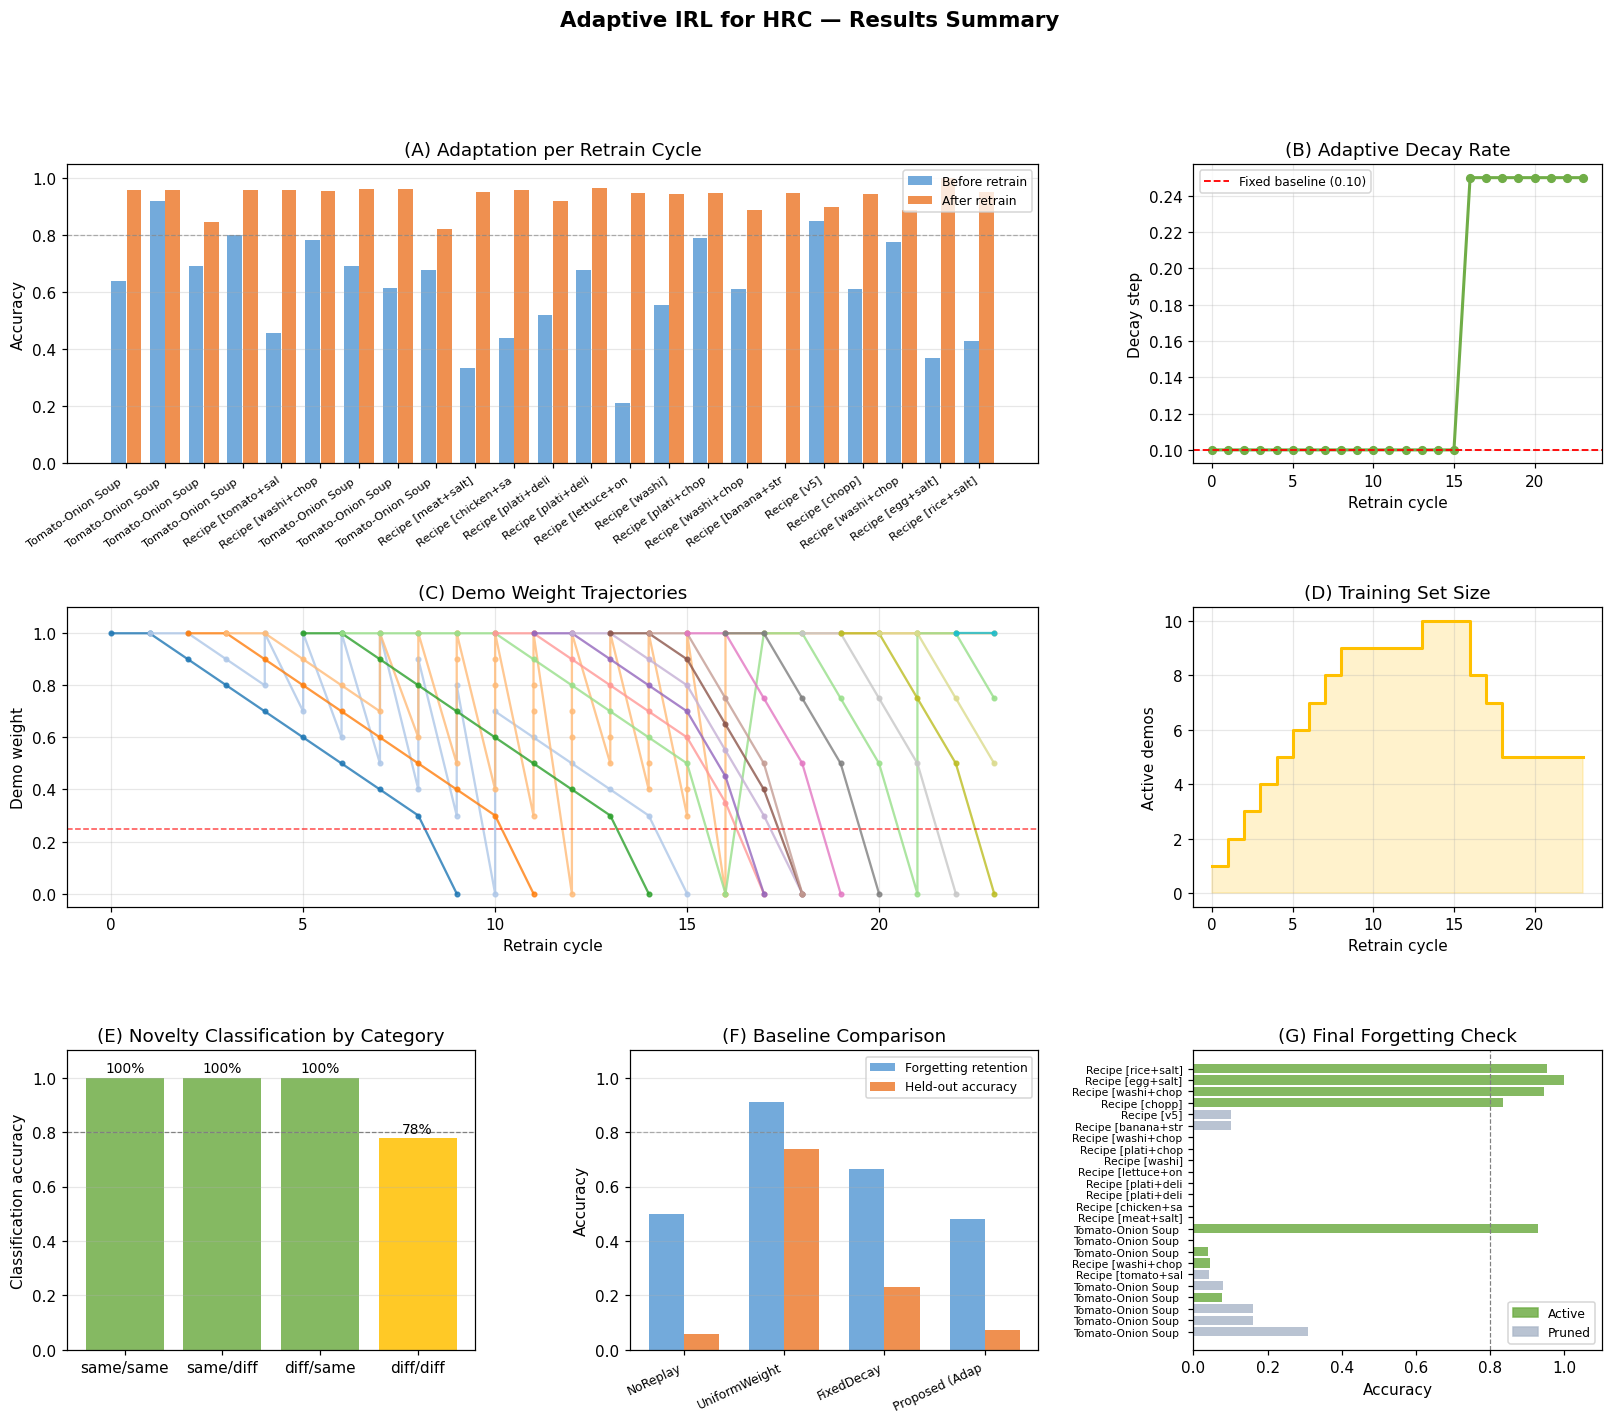

✓ Figure saved to IRL_results.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Adaptive IRL for HRC — Results Summary", fontsize=14, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── Panel A: Accuracy before vs after retrain ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
if acc_history:
    cycles  = [h[0] for h in acc_history]
    befores = [h[2] for h in acc_history]
    afters  = [h[3] for h in acc_history]
    labels  = [h[1][:18] for h in acc_history]
    x = range(len(cycles))
    ax1.bar([i - 0.2 for i in x], befores, width=0.38, label="Before retrain",
            color="#5B9BD5", alpha=0.85)
    ax1.bar([i + 0.2 for i in x], afters,  width=0.38, label="After retrain",
            color="#ED7D31", alpha=0.85)
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.5)
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel("Accuracy"); ax1.set_title("(A) Adaptation per Retrain Cycle")
    ax1.legend(fontsize=8); ax1.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.6)
    ax1.grid(axis="y", alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No retrain events", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("(A) Adaptation per Retrain Cycle")

# ── Panel B: Adaptive decay history ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if len(decay_history) > 1:
    cycs = [h[0] for h in decay_history]
    decs = [h[2] for h in decay_history]
    ax2.plot(cycs, decs, marker="o", color="#70AD47", linewidth=2, markersize=5)
    ax2.axhline(system.base_decay_step, color="red", linestyle="--", lw=1.2,
                label=f"Fixed baseline ({system.base_decay_step:.2f})")
    ax2.set_xlabel("Retrain cycle"); ax2.set_ylabel("Decay step")
    ax2.set_title("(B) Adaptive Decay Rate")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("(B) Adaptive Decay Rate")

# ── Panel C: Demo weight evolution ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
# FIX: plt.cm.get_cmap removed in matplotlib 3.9+
n_colors = max(1, len(demo_lifetimes))
cmap = matplotlib.colormaps["tab20"].resampled(n_colors)
for idx_dl, (lbl, history) in enumerate(demo_lifetimes.items()):
    if len(history) < 2: continue
    cycles_dl  = [h[0] for h in history]
    weights_dl = [h[1] for h in history]
    ax3.plot(cycles_dl, weights_dl, marker=".", linewidth=1.5,
             color=cmap(idx_dl), label=lbl[:22], alpha=0.8)
ax3.axhline(system.weight_removal_threshold, color="red", linestyle="--",
            lw=1, alpha=0.7, label="Removal threshold")
ax3.set_xlabel("Retrain cycle"); ax3.set_ylabel("Demo weight")
ax3.set_title("(C) Demo Weight Trajectories")
ax3.set_ylim(-0.05, 1.1); ax3.grid(alpha=0.3)
if len(demo_lifetimes) <= 12:
    ax3.legend(fontsize=6, ncol=2, loc="lower left")

# ── Panel D: Training set size over time ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
if set_size_history:
    ssh_cycles = [h[0] for h in set_size_history]
    ssh_sizes  = [h[1] for h in set_size_history]
    ax4.step(ssh_cycles, ssh_sizes, where="post", color="#FFC000", linewidth=2)
    ax4.fill_between(ssh_cycles, ssh_sizes, step="post", alpha=0.2, color="#FFC000")
    ax4.set_xlabel("Retrain cycle"); ax4.set_ylabel("Active demos")
    ax4.set_title("(D) Training Set Size")
    ax4.grid(alpha=0.3)

# ── Panel E: Novelty classification confusion ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
categories = ["same/same", "same/diff", "diff/same", "diff/diff"]
cat_keys   = ["same_recipe_same_pref", "same_recipe_diff_pref",
               "diff_recipe_same_pref", "diff_recipe_diff_pref"]
exp_n_map  = [False, True, True, True]
accs_class = []
for ck, en in zip(cat_keys, exp_n_map):
    rows = [r for r in results_table if r["category"] == ck]
    accs_class.append(sum(1 for r in rows if r["is_novel"] == en) / len(rows) if rows else 0.0)
colors_c = ["#70AD47" if a >= 0.8 else ("#FFC000" if a >= 0.6 else "#FF0000") for a in accs_class]
ax5.bar(categories, accs_class, color=colors_c, alpha=0.85)
ax5.axhline(0.8, color="grey", linestyle="--", lw=0.8)
ax5.set_ylim(0, 1.1); ax5.set_ylabel("Classification accuracy")
ax5.set_title("(E) Novelty Classification by Category"); ax5.grid(axis="y", alpha=0.3)
for i, v in enumerate(accs_class):
    ax5.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)

# ── Panel F: Baseline comparison ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
if baseline_results:
    bnames = list(baseline_results.keys())
    x_bl   = np.arange(len(bnames))
    width  = 0.35
    bars1  = [baseline_results[n]["forgetting"] for n in bnames]
    bars2  = [baseline_results[n]["held_out"]   for n in bnames]
    ax6.bar(x_bl - width/2, bars1, width, label="Forgetting retention", color="#5B9BD5", alpha=0.85)
    ax6.bar(x_bl + width/2, bars2, width, label="Held-out accuracy",    color="#ED7D31", alpha=0.85)
    ax6.set_xticks(x_bl)
    ax6.set_xticklabels([n[:14] for n in bnames], rotation=25, ha="right", fontsize=8)
    ax6.set_ylim(0, 1.1); ax6.set_ylabel("Accuracy"); ax6.set_title("(F) Baseline Comparison")
    ax6.legend(fontsize=8); ax6.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.6)
    ax6.grid(axis="y", alpha=0.3)

# ── Panel G: Forgetting check final ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
final_accs, final_lbls, final_acts = [], [], []
wlu = {e["label"]: e["weight"] for e in system.train_demos}
for lbl, demo_fc in labeled_demos:
    acc_fc, _, _, _ = _eval_demo_silent(demo_fc, system)
    final_accs.append(acc_fc)
    final_lbls.append(lbl[:18])
    final_acts.append(wlu.get(lbl, 0.0) > 0)
colors_g = ["#70AD47" if a else "#ADB9CA" for a in final_acts]
ax7.barh(range(len(final_accs)), final_accs, color=colors_g, alpha=0.85)
ax7.set_yticks(range(len(final_lbls)))
ax7.set_yticklabels(final_lbls, fontsize=7)
ax7.set_xlim(0, 1.1)
ax7.axvline(0.8, color="grey", linestyle="--", lw=0.8)
ax7.set_title("(G) Final Forgetting Check")
ax7.set_xlabel("Accuracy")
active_patch = mpatches.Patch(color="#70AD47", alpha=0.85, label="Active")
pruned_patch = mpatches.Patch(color="#ADB9CA", alpha=0.85, label="Pruned")
ax7.legend(handles=[active_patch, pruned_patch], fontsize=8)

# FIX: save to current directory, not container-specific path
plt.savefig("IRL_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to IRL_results.png")